# Práctica III: Aerolíneas y Satisfacción

Elena & Carlos Garrido del Toro

Inteligencia Artificial a 14 de Enero de 2026

---

## 1. Introducción y Objetivos

El objetivo principal de este ejercicio es aplicar conceptos y técnicas de **Aprendizaje Automático Supervisado** .Trabajaremos con el conjunto de datos *Airline Passenger Satisfaction Dataset*, el cual contiene información demográfica de pasajeros, detalles de sus vuelos y puntuaciones sobre servicios específicos (wifi, comida, comodidad, etc.).

El objetivo es predecir la variable `satisfaction` (si un pasajero está "Satisfecho" o "Neutral/Insatisfecho"). Para ello, compararemos el rendimiento de los siguientes modelos:

1.  Perceptrón
2.  Regresión Logística
3.  Máquinas de Vectores de Soporte (SVM)
4.  Árboles de Decisión
5.  Bosques Aleatorios (Random Forest)

In [40]:
# Importación de librerías fundamentales requeridas 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para mostrar gráficos integrados
%matplotlib inline

# Importación de herramientas de preprocesamiento
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Importación de librerías para clustering
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


print("Entorno configurado correctamente. Listo para cargar datos.")

Entorno configurado correctamente. Listo para cargar datos.


Importamos el DataSet descargado y ubicado en la carpeta del proyecto

In [41]:
import pandas as pd
pd.set_option('display.max_columns', None)
df = pd.read_csv("airline_passenger_satisfaction.csv")

## 2. Preprocesamiento

Para poder tratar los datos con nuestros modelos de aprendizaje debemos de normalizar los datos, tratar las variables categóricas y tratar las variables nulas (NaNs)

### 2.1 Selecció de característiques (Feature Selection)

In [42]:
# Muestra las primeras filas para ver la estructura
print(f"Dimensions del dataset: {df.shape}")
display(df.head())

Dimensions del dataset: (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,3,4,3,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.0,satisfied


Nuestros datos contienen 25976 filas y 25 columnas de las cuales debemos eliminar las dos primera columnas `Unnamed` e `id` que no aportan información útil para la predicción.

In [43]:
# Eliminalos las columans que no son necesarias
cols_to_drop = ['Unnamed: 0', 'id']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Miramos las columnas restantes
print(df.columns.tolist())

['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


### 2.2 Limpieza y Transformación de Datos

#### Gestión de Valores Nulos (NaNs)

Los valores perdidos o nulos (NaNs) en un conjunto de datos pueden impedir el correcto funcionamiento de los algoritmos, ya que estos no pueden operar sobre datos inexistentes. Por ello, es imprescindible tratarlos antes de iniciar el entrenamiento.

Existen diversas técnicas para resolver este problema:
1.  **Eliminar filas:** Descartar los registros que contengan algún valor nulo.
2.  **Eliminar columnas:** Descartar la variable completa si tiene demasiados ausentes.
3.  **Imputación por valor fijo:** Sustituir el nulo por una constante.
4.  **Imputación estadística:** Sustituir el nulo por una medida de tendencia central, como la **media** o la mediana.

Nos hemos decantado por usar una estrategia híbrida:
* Para las **variables numéricas** (como *Arrival Delay*), sustituimos los valores faltantes con la **media** de la columna. Esto nos permite conservar la fila y no perder información valiosa del resto de características del pasajero.
* Para la **variable objetivo** (`satisfaction`), eliminaremos las filas que no tengan este dato. Al ser la etiqueta que queremos predecir (nuestra "verdad"), inventar este dato introduciría ruido y falsedades en el entrenamiento supervisado.

In [44]:
# 1. Eliminamos las filas donde no tenemos la variable objetivo 'satisfaction'
df.dropna(subset=['satisfaction'], inplace=True)

# 2. Para el resto de columnas numéricas, rellenamos con la media (Imputación)
# Seleccionamos solo columnas numéricas para evitar errores con las de texto
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Verificamos que ya no queden nulos
print(f"Nulos restantes: {df.isna().sum().sum()}")

Nulos restantes: 0


#### Conversión de Numeros 
Ahora procedemos a convertir las variables de texto en números para que los modelos de aprendizaje puedan trabajar con ellos.
1. `Gender` (Male/Female).
2. `Customer Type` (Loyal/Disloyal).
3. `Type of Travel` (Business / Personal).
4. `Class` (Business / Eco / Eco Plus).
5. `Satisfaction` (satisfied / neutral or dissatisfied) -> Variable Objetivo

In [45]:

# Lista de columnas categóricas (texto) en el dataset de Aerolíneas
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

# Creamos el codificador
le = LabelEncoder()

# Aplicamos la transformación a cada columna
for col in categorical_cols:
    # Ajustamos y transformamos la columna
    df[col] = le.fit_transform(df[col])
    
    # Imprimimos qué número se ha asignado a cada texto para tenerlo de referencia
    print(f"Codificación para '{col}':")
    for i, class_name in enumerate(le.classes_):
        print(f"  {class_name} -> {i}")
    print("\n")

print("\nDataset transformado a numérico")
display(df.head())

Codificación para 'Gender':
  Female -> 0
  Male -> 1


Codificación para 'Customer Type':
  Loyal Customer -> 0
  disloyal Customer -> 1


Codificación para 'Type of Travel':
  Business travel -> 0
  Personal Travel -> 1


Codificación para 'Class':
  Business -> 0
  Eco -> 1
  Eco Plus -> 2


Codificación para 'satisfaction':
  neutral or dissatisfied -> 0
  satisfied -> 1



Dataset transformado a numérico


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,0,52,0,1,160,5,4,3,4,3,4,3,5,5,5,5,2,5,5,50,44.0,1
1,0,0,36,0,0,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.0,1
2,1,1,20,0,1,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.0,0
3,1,0,44,0,0,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.0,1
4,0,0,49,0,1,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.0,1


#### Normalización de Datos

Finalmente, para completar el preprocesamiento del dataset, es indispensable **normalizar los datos**. Actualmente, tenemos variables con escalas muy diferentes; por ejemplo, `Flight Distance` tiene valores en los miles (ej: 3000 km), mientras que `Age` o las puntuaciones de encuestas se mueven en rangos mucho menores (0-5 o 0-100).

Esta diferencia en las escalas es problematica, ya que, hace que los algoritmos basados en distancias (como **SVM** o **K-Means**) fallen o den más importancia errónea a las variables con números más grandes. Además, provoca que el entrenamiento de modelos como la **Regresión Logística** o el **Perceptrón** sea mucho más lento al dificultar la convergencia.

Para solucionar esto, aplicaremos `StandardScaler` (Estandarización), transformando las variables para que tengan una media de 0 y una desviación estándar de 1.

In [46]:

# No queremos normalizar 'satisfaction', es el objetivo
target = 'satisfaction'
X = df.drop(target, axis=1)
y = df[target]

# Inicializamos el escalador
scaler = StandardScaler()

# Ajustamos y transformamos los datos
# Devuelve un array de numpy, así que lo volvemos a convertir a DataFrame para no perder los nombres de columnas
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(" Datos Normalizados (Primeras filas)")
display(X_scaled.head())

# Descripción para ver que la media es 0 y la desviación estándar es 1
print("\nEstadísticas tras la normalización")
display(X_scaled.describe().round(2))

 Datos Normalizados (Primeras filas)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,-0.985932,-0.476040,0.817887,-0.663378,0.652923,-1.035171,1.703853,0.621641,0.172143,0.797831,-0.161739,0.544692,-0.340303,1.227138,1.259170,1.250974,1.161716,-1.035348,1.144063,1.298998,0.953810,0.781143
1,-0.985932,-0.476040,-0.239238,-0.663378,-0.950436,1.671443,-1.291598,-1.334871,0.172143,-1.542065,1.340348,0.544692,1.174774,0.479907,0.479178,0.492730,0.311739,-0.247517,0.297077,1.298998,-0.382286,-0.393543
2,1.014269,2.100665,-1.296363,-0.663378,0.652923,-1.003128,-0.542735,-1.987042,-0.535609,0.797831,-0.912783,-0.930768,-1.097842,-1.014556,0.479178,-1.782001,-0.538238,-1.035348,-1.396893,-0.974927,-0.382286,-0.393543
3,1.014269,-0.476040,0.289325,-0.663378,-0.950436,2.186131,-2.040460,-1.987042,-1.951114,-0.762100,-0.161739,0.544692,0.417235,-1.761787,-1.860800,-1.782001,-2.238193,-0.247517,-2.243878,0.541023,-0.382286,-0.233358
4,-0.985932,-0.476040,0.619676,-0.663378,0.652923,-0.011804,-0.542735,-0.030530,0.879895,0.017866,0.589304,-1.668498,-1.097842,-1.014556,-1.080807,-1.023758,-1.388216,0.540315,-1.396893,0.541023,-0.382286,0.140405



Estadísticas tras la normalización


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00
mean,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.99,-0.48,-2.16,-0.66,-0.95,-1.16,-2.04,-1.99,-1.95,-1.54,-2.41,-2.41,-1.86,-2.51,-2.64,-2.54,-2.24,-1.82,-3.09,-2.49,-0.38,-0.39
25%,-0.99,-0.48,-0.83,-0.66,-0.95,-0.78,-0.54,-0.68,-0.54,-0.76,-0.91,-0.93,-1.10,-1.01,-1.08,-1.02,-0.54,-0.25,-0.55,-0.97,-0.38,-0.39
50%,-0.99,-0.48,0.03,-0.66,0.65,-0.35,0.21,-0.03,0.17,0.02,-0.16,0.54,0.42,0.48,0.48,0.49,0.31,-0.25,0.30,-0.22,-0.38,-0.39
75%,1.01,-0.48,0.75,1.51,0.65,0.55,0.95,0.62,0.88,0.80,0.59,0.54,1.17,0.48,0.48,0.49,1.16,0.54,1.14,0.54,-0.06,-0.05
max,1.01,2.10,3.00,1.51,2.26,3.79,1.70,1.27,1.59,1.58,1.34,1.28,1.17,1.23,1.26,1.25,1.16,1.33,1.14,1.30,29.76,29.37


## 3. Análisis Exploratorio de Datos (EDA)

El siguiente paso consiste en agrupar a los pasajeros automáticamente mediante técnicas de aprendizaje no supervisado. El objetivo es descubrir si existen perfiles de usuarios diferenciados (por ejemplo, 'Viajeros de negocios exigentes' frente a 'Turistas relajados') antes de abordar la predicción supervisada.

Realizamos esto para comprender mejor la estructura de los datos y detectar qué características (edad, clase, distancia) definen realmente el comportamiento de los pasajeros.

Antes de ejecutar el algoritmo K-Means, debemos determinar qué número de grupos ($k$) es el más eficiente. Para ello, nos apoyaremos en el Método del Codo (Elbow Method), una técnica que nos permite visualizar gráficamente el punto de inflexión donde se optimiza la relación entre el número de clústeres y la cohesión de los mismos. [Fuente del método](https://jarroba.com/seleccion-del-numero-optimo-clusters/#google_vignette)

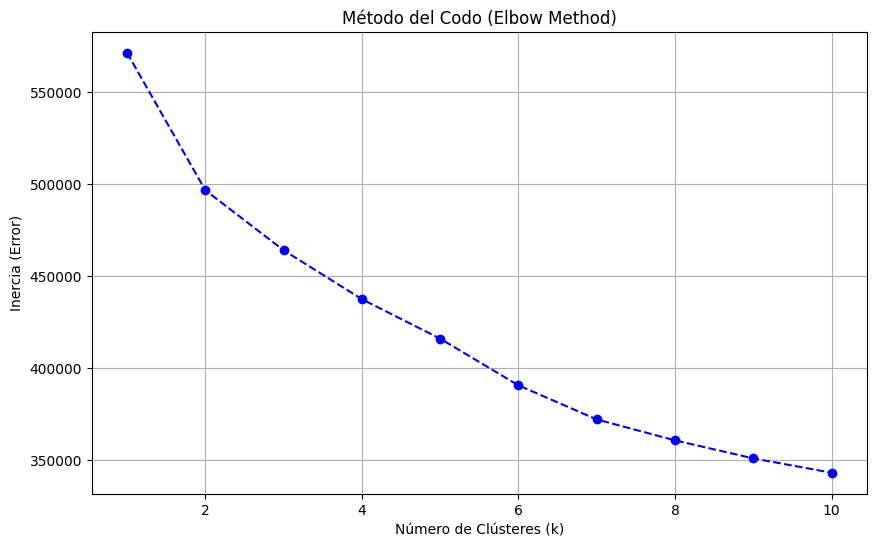

In [47]:
# Definimos un rango de 1 a 10 posibles grupos (clusters)
inertia = []
K_range = range(1, 11)

# Probamos K-Means con diferentes cantidades de grupos
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)  # Usamos los datos normalizados 
    inertia.append(kmeans.inertia_)

# Dibujamos la Gráfica del Codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia (Error)')
plt.grid(True)
plt.show()

Analizando la gráfica, observamos que el primer punto de inflexión (codo) se encuentra en $k=2$. Sin embargo, dado que en $k=3$ la pendiente sigue mostrando una mejora similar, nos decantamos por escoger $k=3$. Esto nos permitirá obtener una mayor granularidad en el análisis, detectando matices en los perfiles de pasajeros que una división binaria podría pasar por alto.

In [48]:
# APLICAR EL CLUSTERING (K=3)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# GUARDAR LOS RESULTADOS
# Creamos una copia del dataset ORIGINAL
df_analisis = df.copy()
df_analisis['Cluster'] = clusters  # Añadimos la columna con el grupo (0, 1 o 2)

# Agrupamos por clúster y sacamos la media de alguna de las variables más importantes
perfil_grupos = df_analisis.groupby('Cluster')[['Age', 'Flight Distance', 'Class', 'Type of Travel', 'satisfaction', 'Inflight wifi service']].mean().round(2)

print("--- CARACTERÍSTICAS QUE DEFINEN CADA GRUPO ---")
display(perfil_grupos)

# Ver cuánta gente hay en cada grupo
print("\n--- Cantidad de pasajeros por grupo ---")
print(df_analisis['Cluster'].value_counts())

--- CARACTERÍSTICAS QUE DEFINEN CADA GRUPO ---


,Age,Flight Distance,Class,Type of Travel,satisfaction,Inflight wifi service
Cluster,,,,,,
0,33.12,838.52,0.88,0.47,0.17,2.35
1,41.93,1043.03,0.76,0.35,0.26,2.53
2,42.13,1538.23,0.28,0.16,0.75,3.12



--- Cantidad de pasajeros por grupo ---
Cluster
2    10822
1     8098
0     7056
Name: count, dtype: int64


## 4.Preparacion para Modelos Supervisados
Ahora procederemos a dividir nuestros datos en dos conjuntos distintos, uno de entrenamiento y otro de prueba. Esta division es importante para poder evaluar nuestros modelos de manera adecuada. 

Hemos considereado dividir los datos de la siguiente manera un (70% ) para entrenamiento y un (30%) para las pruebas, asi podremos evaluar el rendimiento con datos que nunca haya visto.

Usamos train_test_split con: test_size= 0.3 (para los de prueba ) y importante destacar el stratify =y que nos mantiene la proporcion de clases para los dos conjuntos 


In [49]:

# Dividimos los datos en entrenamiento (70%) y prueba (30%)
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Dimensiones del conjunto de entrenamiento: {X_train.shape}")
print(f"Dimensiones del conjunto de prueba: {X_test.shape}")
print(f"\nDistribución de clases en entrenamiento:\n{y_train.value_counts(normalize=True)}")
print(f"\nDistribución de clases en prueba:\n{y_test.value_counts(normalize=True)}")

Dimensiones del conjunto de entrenamiento: (18183, 22)
Dimensiones del conjunto de prueba: (7793, 22)

Distribución de clases en entrenamiento:
satisfaction
0    0.561019
1    0.438981
Name: proportion, dtype: float64

Distribución de clases en prueba:
satisfaction
0    0.561016
1    0.438984
Name: proportion, dtype: float64


## 4.2 Definición de Métricas de Evaluacion 
para comparar los diferentes modelos necesitamos diferentes metricas para observar distintos aspectos de su rendimiento. 

Metricas Implementadas: 

1. Accuaracy(Precisión).

2. Matriz de Confusión.

3. Precision.

4. Recall(Sensibilidad).

5. F1-Score.

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# Función de cálculo de métricas
def evaluar_modelo(modelo, X_train, X_test, y_train, y_test, nombre_modelo):
    modelo.fit(X_train, y_train)
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_test = accuracy_score(y_test, y_test_pred)
    cm = confusion_matrix(y_test, y_test_pred)
    report = classification_report(y_test, y_test_pred, output_dict=True)
    
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
        
    resultados = {
        'Modelo': nombre_modelo,
        'Accuracy Train': accuracy_train,
        'Accuracy Test': accuracy_test,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Confusion Matrix': cm,
        'Classification Report': report
    }
    return resultados

# Visualización 
def mostrar_resultados(resultados, modelo, X_test, y_test):
    # Estilo
    line_width = 80
    print("\n" + "=" * line_width)
    print(f"{'RESULTADOS DETALLADOS':^{line_width}}")
    print("=" * line_width)
    print(f"\nModelo: {resultados['Modelo']}")
    print("-" * line_width)
    
    #  MÉTRICAS
    print(f"\n{'MÉTRICAS PRINCIPALES':^{line_width}}")
    print("-" * line_width)
    
    metrics_data = [
        ["Métrica", "Entrenamiento", "Prueba"],
        ["Accuracy", f"{resultados['Accuracy Train']:.4f}", f"{resultados['Accuracy Test']:.4f}"],
        ["Precision", "-", f"{resultados['Precision']:.4f}"],
        ["Recall", "-", f"{resultados['Recall']:.4f}"],
        ["F1-Score", "-", f"{resultados['F1-Score']:.4f}"]
    ]
    
    col_widths = [max(len(str(row[i])) for row in metrics_data) for i in range(3)]
    for i, row in enumerate(metrics_data):
        if i == 0: print("-" * (sum(col_widths) + 8))
        formatted_row = " | ".join(f"{str(cell):<{col_widths[j]}}" for j, cell in enumerate(row))
        print(f"| {formatted_row} |")
        if i == 0: print("-" * (sum(col_widths) + 8))
    print("-" * (sum(col_widths) + 8))
    
    #  MATRIZ DE CONFUSIÓN (GRÁFICO) 
    print(f"\n{'MATRIZ DE CONFUSIÓN':^{line_width}}")
    print("-" * line_width)
    
    # Usamos ConfusionMatrixDisplay para dibujar
    cm = resultados['Confusion Matrix']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutral/Dissatisfied', 'Satisfied'])
    
    # Creamos la figura
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
    plt.title(f"Matriz de Confusión: {resultados['Modelo']}")
    plt.grid(False) 
    plt.show()

    #  MATRIZ DE CONFUSIÓN (Explicación)
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    
    aciertos = tn + tp
    errores = fp + fn
    porc_aciertos = (aciertos / total) * 100
    porc_errores = (errores / total) * 100
    
    print(f"\n{'DESGLOSE DETALLADO DE LA MATRIZ':^{line_width}}")
    print("-" * line_width)
    print(f"Total de muestras evaluadas: {total}")
    
    print(f"\nACIERTOS (Predicciones Correctas): {aciertos} ({porc_aciertos:.2f}%)")
    print(f"     > Verdaderos Negativos (TN): {tn:<5} (Predijo 'Insatisfecho' y era correcto)")
    print(f"     > Verdaderos Positivos (TP): {tp:<5} (Predijo 'Satisfecho' y era correcto)")
    
    print(f"\nERRORES (Predicciones Incorrectas): {errores} ({porc_errores:.2f}%)")
    print(f"     > Falsos Positivos (FP - Tipo I) : {fp:<5} (Predijo 'Satisfecho' pero NO lo estaba)")
    print(f"     > Falsos Negativos (FN - Tipo II): {fn:<5} (Predijo 'Insatisfecho' pero SÍ lo estaba)")

    print(f"\n{'REPORTE DE CLASIFICACIÓN':^{line_width}}")
    print("-" * line_width)
    
    report = resultados['Classification Report']
    report_df = pd.DataFrame({
        'Clase': ['0 (Insatisfecho)', '1 (Satisfecho)', 'Macro Avg', 'Weighted Avg'],
        'Precision': [f"{report['0']['precision']:.4f}", f"{report['1']['precision']:.4f}", f"{report['macro avg']['precision']:.4f}", f"{report['weighted avg']['precision']:.4f}"],
        'Recall': [f"{report['0']['recall']:.4f}", f"{report['1']['recall']:.4f}", f"{report['macro avg']['recall']:.4f}", f"{report['weighted avg']['recall']:.4f}"],
        'F1-Score': [f"{report['0']['f1-score']:.4f}", f"{report['1']['f1-score']:.4f}", f"{report['macro avg']['f1-score']:.4f}", f"{report['weighted avg']['f1-score']:.4f}"],
        'Soporte': [f"{int(report['0']['support'])}", f"{int(report['1']['support'])}", f"{int(report['macro avg']['support'])}", f"{int(report['weighted avg']['support'])}"]
    })
    print("\n" + report_df.to_string(index=False))

    
    #  ANÁLISIS DE RENDIMIENTO 
    print(f"\n{'ANÁLISIS DE RENDIMIENTO':^{line_width}}")
    print("-" * line_width)
    
    diff_acc = resultados['Accuracy Train'] - resultados['Accuracy Test']
    if abs(diff_acc) < 0.01: ajuste = "EQUILIBRADO - Buena generalización"
    elif diff_acc > 0.05: ajuste = "POSIBLE SOBREAJUSTE (Overfitting)"
    elif diff_acc < -0.02: ajuste = "POSIBLE SUBAJUSTE (Underfitting)"
    else: ajuste = "AJUSTE MODERADO - Diferencia aceptable"
    
    print(f"\nDiferencia Accuracy (Entrenamiento - Prueba): {diff_acc:+.4f}")
    print(f"Estado del ajuste: {ajuste}")
    
    precision_val = resultados['Precision']
    recall_val = resultados['Recall']
    if abs(precision_val - recall_val) < 0.05: balance = "BALANCEADO"
    elif precision_val > recall_val: balance = f"PRECISIÓN ALTA (Minimiza Falsos Positivos)"
    else: balance = f"RECALL ALTO (Minimiza Falsos Negativos)"
    
    print(f"Balance Precisión-Recall: {balance}")
    print("\n" + "=" * line_width)
    
    return resultados

## 5. Entrenamiento de los modelos.
### 5.1. Perceptron.

Para el Perceptron hemos decidido escoger estos hiperparametros y implementarlos para descubrir cual es el que mejor resulatdos nos da, teniendo en cuenta que si cubrimos demasiado poco puede ser inestable y si cubrimos demasiado puede ser demasiado lento. 

Tenemos para `max_iter` 100, 500 y 1000, hemos codigo 1000 por si a caso nuestro dataser es complejo y necesita mas convergencia.

Por otra parte tenemos `eta0` con 0.1, 0.01, 0.001  estos nos determinan la tasa de aprendizaje inicial.

#### Estrategia de Validacion

Hemos implementado un `5-fold-cross-validation` esto significa que del 70 % que le hemos dado de los datos para entrenar, lo divide en 5 secciones, entrena 4 folds y valida 1 fold, repitiendolo 5 veces. Esto nos ayuda a ajustar los hiperparametros, eviatr sobreajustes y mejoramos la estiamacion del rendimiento

¿Cómo consideramos cuales son los mejores hiperparametros?
La metrica de evaluacion es `accuracy` (precision ), consideramos que precision seria una buena metrica ya que tenemos unas clases balanceadas, pudiendonos dar asi precision unos datos relevantes para poder comoparar los diferentes modelos de la combinacion de hiperparametros.



In [51]:
from sklearn.linear_model import Perceptron
from sklearn.model_selection import GridSearchCV

# Definir el modelo base
perceptron = Perceptron(random_state=42)

# Definir la grilla de hiperparámetros
param_grid_perceptron = {
    'max_iter': [100, 500, 1000],
    'eta0': [0.1, 0.01, 0.001]
}

# Búsqueda de mejores hiperparámetros con validación cruzada
grid_perceptron = GridSearchCV(
    perceptron, 
    param_grid_perceptron, 
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Métrica de evaluación
    n_jobs=-1,  # Usar todos los núcleos disponibles
    verbose=1
)

# Entrenar con búsqueda de hiperparámetros
grid_perceptron.fit(X_train, y_train)

print(f"Mejores hiperparámetros para Perceptrón: {grid_perceptron.best_params_}")
print(f"Mejor score en validación cruzada: {grid_perceptron.best_score_:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Mejores hiperparámetros para Perceptrón: {'eta0': 0.1, 'max_iter': 100}
Mejor score en validación cruzada: 0.7904


Ahora lo que hacemos es coger los mejores hiperparametros que hemos conseguido y evaluamos el modelo con los datos de prueba intactos el 30 % 


                             RESULTADOS DETALLADOS                              

Modelo: Perceptrón
--------------------------------------------------------------------------------

                              MÉTRICAS PRINCIPALES                              
--------------------------------------------------------------------------------
------------------------------------
| Métrica   | Entrenamiento | Prueba |
------------------------------------
| Accuracy  | 0.8297        | 0.8260 |
| Precision | -             | 0.8141 |
| Recall    | -             | 0.7822 |
| F1-Score  | -             | 0.7979 |
------------------------------------

                              MATRIZ DE CONFUSIÓN                               
--------------------------------------------------------------------------------


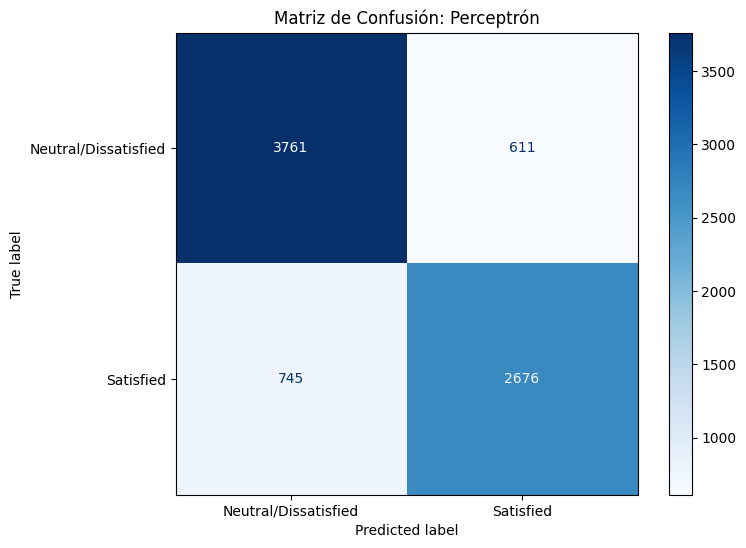


                        DESGLOSE DETALLADO DE LA MATRIZ                         
--------------------------------------------------------------------------------
Total de muestras evaluadas: 7793

ACIERTOS (Predicciones Correctas): 6437 (82.60%)
     > Verdaderos Negativos (TN): 3761  (Predijo 'Insatisfecho' y era correcto)
     > Verdaderos Positivos (TP): 2676  (Predijo 'Satisfecho' y era correcto)

ERRORES (Predicciones Incorrectas): 1356 (17.40%)
     > Falsos Positivos (FP - Tipo I) : 611   (Predijo 'Satisfecho' pero NO lo estaba)
     > Falsos Negativos (FN - Tipo II): 745   (Predijo 'Insatisfecho' pero SÍ lo estaba)

                            REPORTE DE CLASIFICACIÓN                            
--------------------------------------------------------------------------------

           Clase Precision Recall F1-Score Soporte
0 (Insatisfecho)    0.8347 0.8602   0.8473    4372
  1 (Satisfecho)    0.8141 0.7822   0.7979    3421
       Macro Avg    0.8244 0.8212   0.8226    7793


In [52]:
# Usar el mejor modelo encontrado
best_perceptron = grid_perceptron.best_estimator_

# Evaluar el modelo
resultados_perceptron = evaluar_modelo(best_perceptron, X_train, X_test, y_train, y_test, "Perceptrón")
mostrar_resultados(resultados_perceptron, best_perceptron, X_test, y_test);

Visualizamos el efecto de los hiperparametros

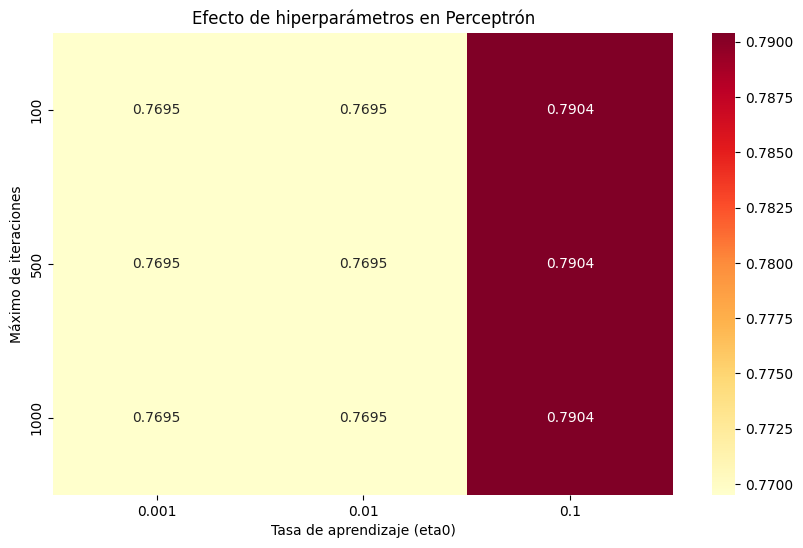

In [53]:
# Análisis de resultados de GridSearchCV
import pandas as pd

# Convertir resultados a DataFrame
cv_results = pd.DataFrame(grid_perceptron.cv_results_)

# Filtrar columnas relevantes
cv_results_filtered = cv_results[['param_max_iter', 'param_eta0', 'mean_test_score', 'std_test_score']]

# Crear pivot table para visualización
pivot_table = cv_results_filtered.pivot_table(
    values='mean_test_score',
    index='param_max_iter',
    columns='param_eta0'
)

# Visualizar heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlOrRd')
plt.title('Efecto de hiperparámetros en Perceptrón')
plt.xlabel('Tasa de aprendizaje (eta0)')
plt.ylabel('Máximo de iteraciones')
plt.show()

### Evaluacion del Perceptron 

A primera vista lo mas destacable es que da diferencia de Accuraacy entre el Entrenamiento y la Prueba es muy pequeña, esto es una buena señal de que el modelo no esta sobreajustado y generaliza bien a datos nuevos.

Tambien observamos un **F1-Score** del 79.79 % que nos indica un equilibrio entre precision y recall.

##### Errores que ha tenido el modelo 
El modelo ha detectado 611 casos de **Falsos Positivos**, es decir hemos tenido 611 pasajeros instatisfechos clasificados como satisfechos. 

Por otra parte hemos tenido 745 casos de **Falsos Negativos** pasajeros que si estaban satisfechos han sido classificados cono insatisfechos.



## 5.2 Regresion Logistica 

Este modelo a priori deberia de aportar buenos resultados ya que destaca por su rendimiento en problemas binarios.

#### Hiperparametros 
para este modelo hemos escogido 3 hiperparametros distintos.
POr una parte tenemos `C`, este controla el ajuste entre los datos de entrenamiento y generalizacion. Cuando mas pequeño es el numero mayor regulizacion porbamos con (0.001, 0.01, 0.1, 1, 10) todo esto para encontrar el balance optimo entre sesgo y varianza.

Luego tenemos `solver ` con diferentes algoritmos para resolver el problema de optimizacion:

`liblinear`: Adecuado para datasets de tamaño moderado (25K muestras).

`lbfgs`:  Bueno para problemas convexos suaves como nuestra función logística.

`sag`: Eficiente para datasets grandes con muchas muestras.

Por ultimo tenemos los valores de max_iter `(100,200,500)`.

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Definir el modelo base
logreg = LogisticRegression(random_state=42, max_iter=1000)

# Definir la grilla de hiperparámetros
param_grid_logreg = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs', 'sag'],
    'max_iter': [100, 200, 500]
}

# Búsqueda de mejores hiperparámetros con validación cruzada
grid_logreg = GridSearchCV(
    logreg, 
    param_grid_logreg, 
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Métrica de evaluación
    n_jobs=-1,  # Usar todos los núcleos disponibles
    verbose=1
)

# Entrenar con búsqueda de hiperparámetros
grid_logreg.fit(X_train, y_train)

print(f"Mejores hiperparámetros para Regresión Logística: {grid_logreg.best_params_}")
print(f"Mejor score en validación cruzada: {grid_logreg.best_score_:.4f}")

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Mejores hiperparámetros para Regresión Logística: {'C': 0.1, 'max_iter': 100, 'solver': 'lbfgs'}
Mejor score en validación cruzada: 0.8711


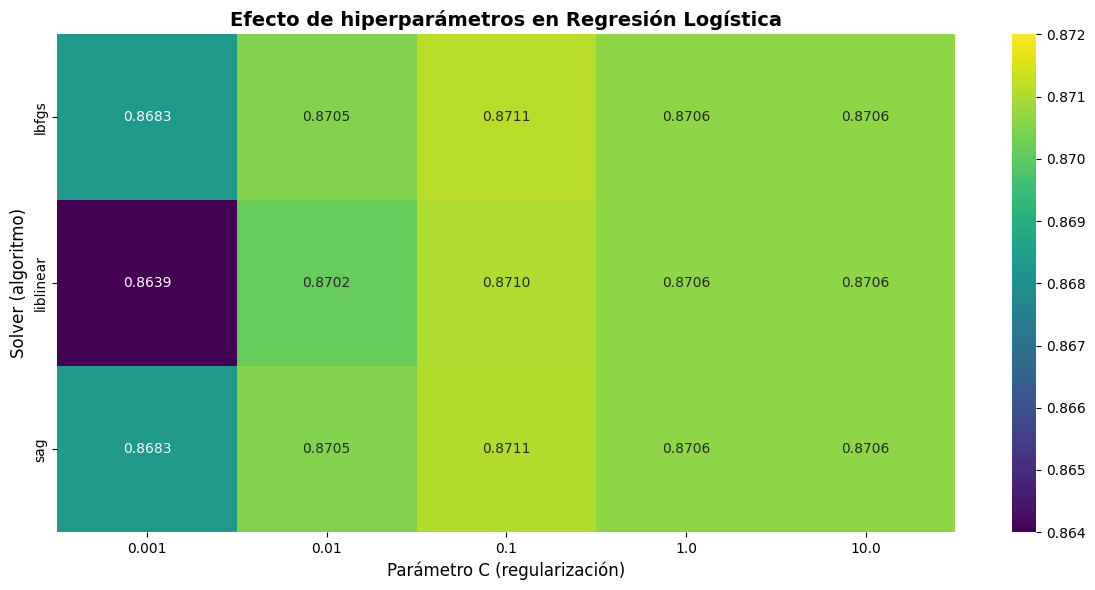

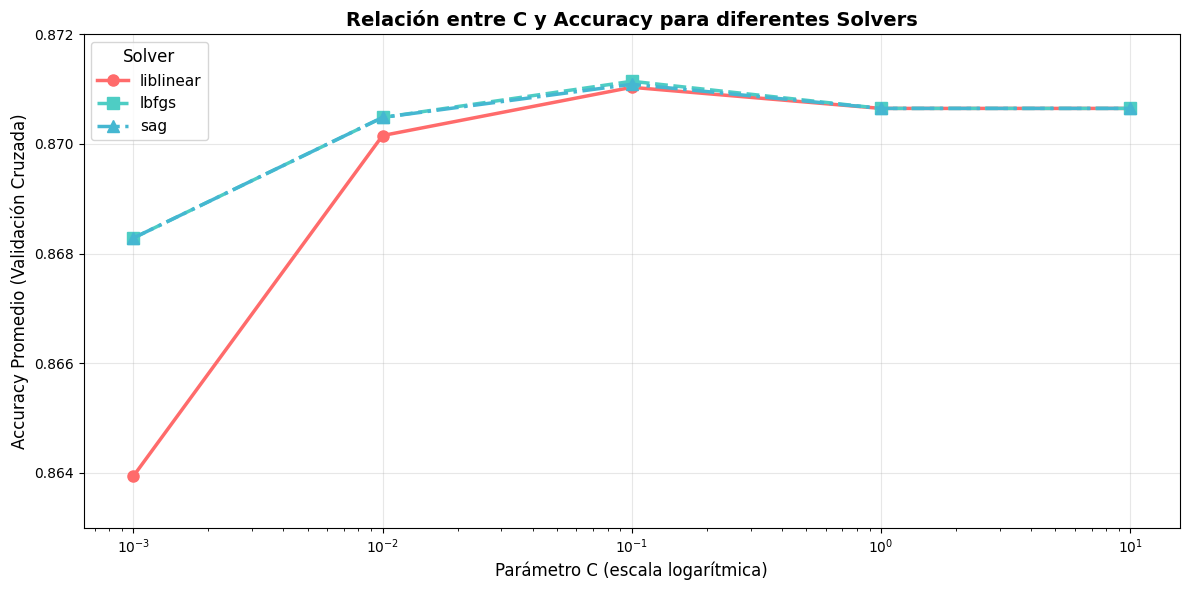

In [55]:
# Convertir resultados a DataFrame
cv_results_logreg = pd.DataFrame(grid_logreg.cv_results_)

# Visualizar efecto de C y solver (promediando sobre max_iter)
cv_results_filtered_logreg = cv_results_logreg[['param_C', 'param_solver', 'mean_test_score']]
mean_scores = cv_results_filtered_logreg.groupby(['param_C', 'param_solver']).mean().reset_index()

# Crear pivot table para visualización
pivot_table_logreg = mean_scores.pivot_table(
    values='mean_test_score',
    index='param_solver',
    columns='param_C'
)

# Visualizar heatmap con mejor rango de colores
plt.figure(figsize=(12, 6))
# Definir un rango de colores más sensible para diferencias pequeñas
# Usamos colormap viridis que tiene buen contraste para rangos estrechos
heatmap = sns.heatmap(pivot_table_logreg, annot=True, fmt='.4f', 
                      cmap='viridis', 
                      vmin=0.864,  # Establecer mínimo explícito
                      vmax=0.872,  # Establecer máximo explícito
                      center=0.868)  # Centrar en el valor medio
plt.title('Efecto de hiperparámetros en Regresión Logística', fontsize=14, fontweight='bold')
plt.xlabel('Parámetro C (regularización)', fontsize=12)
plt.ylabel('Solver (algoritmo)', fontsize=12)
plt.tight_layout()
plt.show()

# Gráfico de líneas con colores más distinguibles
plt.figure(figsize=(12, 6))

# Definir colores distintos y fácilmente distinguibles
colors = {'liblinear': '#FF6B6B',  # Rojo coral
          'lbfgs': '#4ECDC4',      # Turquesa
          'sag': '#45B7D1'}        # Azul claro

# Definir marcadores diferentes también para mayor claridad
markers = {'liblinear': 'o', 
           'lbfgs': 's', 
           'sag': '^'}

line_styles = {'liblinear': '-', 
               'lbfgs': '--', 
               'sag': '-.'}

for solver in ['liblinear', 'lbfgs', 'sag']:
    solver_data = mean_scores[mean_scores['param_solver'] == solver]
    plt.plot(solver_data['param_C'].astype(float), solver_data['mean_test_score'], 
             marker=markers[solver], 
             label=solver, 
             linewidth=2.5,
             color=colors[solver],
             linestyle=line_styles[solver],
             markersize=8)

plt.xscale('log')  # Escala logarítmica para C
plt.title('Relación entre C y Accuracy para diferentes Solvers', fontsize=14, fontweight='bold')
plt.xlabel('Parámetro C (escala logarítmica)', fontsize=12)
plt.ylabel('Accuracy Promedio (Validación Cruzada)', fontsize=12)
plt.grid(True, alpha=0.3)

# Ajustar límites del eje Y para ver mejor las diferencias
plt.ylim(0.863, 0.872)  # Rango ligeramente mayor que el de los datos para mejor visualización

# Mejorar la leyenda
plt.legend(title='Solver', title_fontsize=12, fontsize=11, loc='best')

plt.tight_layout()
plt.show()

Como podemos observar la mejor combinacion de Hiperparametros ha sido: `{'C': 0.1, 'max_iter': 100, 'solver': 'lbfgs'}`. Deberiamos destacar que la competicion ha sido muy reñida, puesto que todos los tipos de solvers al 0.1 de C han dado resultados muy buenos, como podemos ver en la grafica en verde claro.


                             RESULTADOS DETALLADOS                              

Modelo: Regresión Logística
--------------------------------------------------------------------------------

                              MÉTRICAS PRINCIPALES                              
--------------------------------------------------------------------------------
------------------------------------
| Métrica   | Entrenamiento | Prueba |
------------------------------------
| Accuracy  | 0.8718        | 0.8704 |
| Precision | -             | 0.8656 |
| Recall    | -             | 0.8343 |
| F1-Score  | -             | 0.8497 |
------------------------------------

                              MATRIZ DE CONFUSIÓN                               
--------------------------------------------------------------------------------


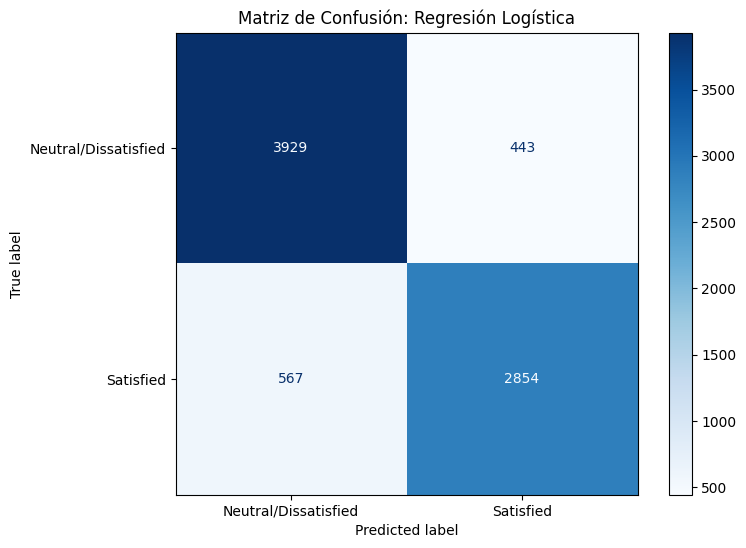


                        DESGLOSE DETALLADO DE LA MATRIZ                         
--------------------------------------------------------------------------------
Total de muestras evaluadas: 7793

ACIERTOS (Predicciones Correctas): 6783 (87.04%)
     > Verdaderos Negativos (TN): 3929  (Predijo 'Insatisfecho' y era correcto)
     > Verdaderos Positivos (TP): 2854  (Predijo 'Satisfecho' y era correcto)

ERRORES (Predicciones Incorrectas): 1010 (12.96%)
     > Falsos Positivos (FP - Tipo I) : 443   (Predijo 'Satisfecho' pero NO lo estaba)
     > Falsos Negativos (FN - Tipo II): 567   (Predijo 'Insatisfecho' pero SÍ lo estaba)

                            REPORTE DE CLASIFICACIÓN                            
--------------------------------------------------------------------------------

           Clase Precision Recall F1-Score Soporte
0 (Insatisfecho)    0.8739 0.8987   0.8861    4372
  1 (Satisfecho)    0.8656 0.8343   0.8497    3421
       Macro Avg    0.8698 0.8665   0.8679    7793


In [56]:
# Usar el mejor modelo encontrado
best_logreg = grid_logreg.best_estimator_

# Evaluar el modelo
resultados_logreg = evaluar_modelo(best_logreg, X_train, X_test, y_train, y_test, "Regresión Logística")
mostrar_resultados(resultados_logreg, best_logreg, X_test, y_test);



Con los datos que nos ha proporcionado podemos observar que con el Accuracy de 87.04% confirmamos que no hay sesgo de clase significativo.

La puntuacion del F1-Score tambien nos da una buena señal de un buen balance entre el precision y el recall.



Visualizacion del efecto de los hiperparametros

Evaluacion Especifica del Modelo

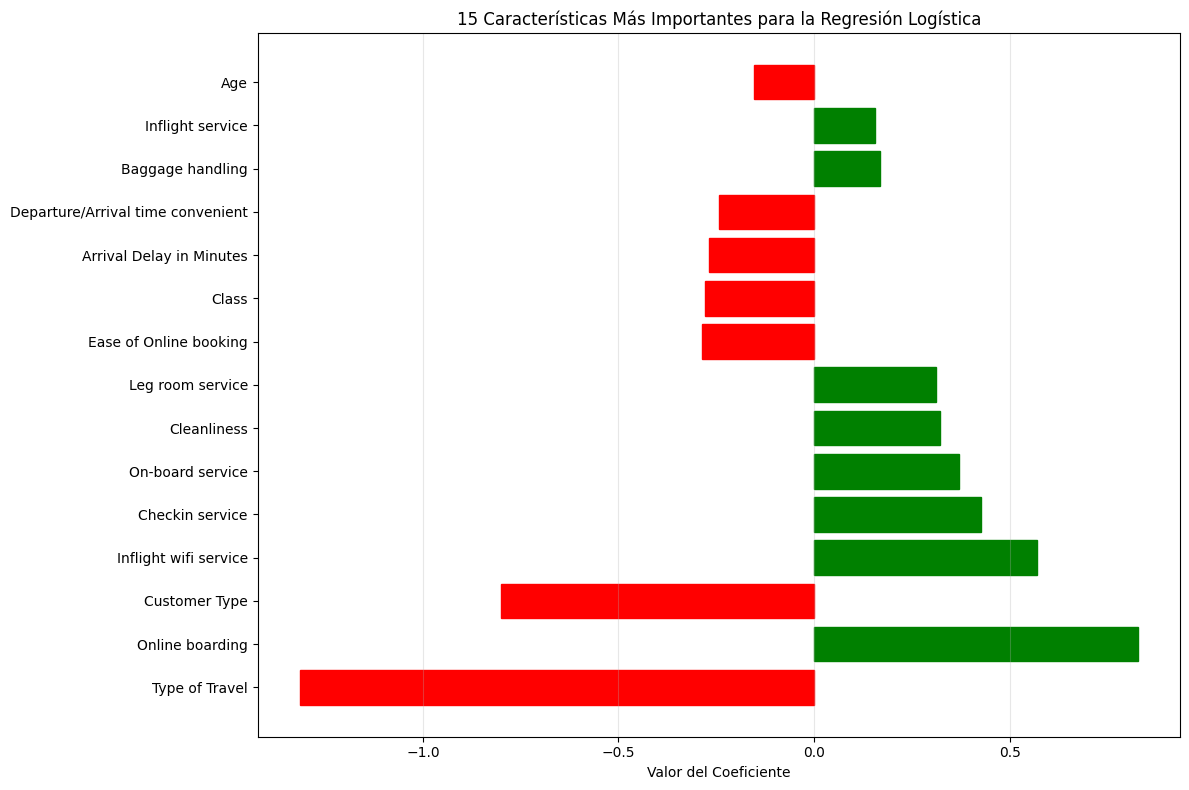

Top 10 características más importantes:


,Característica,Coeficiente,Importancia_Absoluta
3,Type of Travel,-1.315546,1.315546
11,Online boarding,0.828445,0.828445
1,Customer Type,-0.800942,0.800942
6,Inflight wifi service,0.570227,0.570227
17,Checkin service,0.427019,0.427019
14,On-board service,0.371430,0.371430
19,Cleanliness,0.322651,0.322651
15,Leg room service,0.311155,0.311155
8,Ease of Online booking,-0.286098,0.286098
4,Class,-0.278145,0.278145


In [57]:
# Obtener coeficientes del modelo para análisis de importancia de características
coeficientes = best_logreg.coef_[0]
caracteristicas = X_scaled.columns

# Crear DataFrame con coeficientes
df_coeficientes = pd.DataFrame({
    'Característica': caracteristicas,
    'Coeficiente': coeficientes,
    'Importancia_Absoluta': np.abs(coeficientes)
})

# Ordenar por importancia absoluta
df_coeficientes = df_coeficientes.sort_values('Importancia_Absoluta', ascending=False)

# Visualizar las 15 características más importantes
plt.figure(figsize=(12, 8))
bars = plt.barh(df_coeficientes['Característica'][:15], df_coeficientes['Coeficiente'][:15])
plt.xlabel('Valor del Coeficiente')
plt.title('15 Características Más Importantes para la Regresión Logística')
plt.grid(True, alpha=0.3, axis='x')

# Colorear barras según signo
for bar in bars:
    if bar.get_width() > 0:
        bar.set_color('green')  # Contribuye a clase positiva (satisfecho)
    else:
        bar.set_color('red')  # Contribuye a clase negativa (insatisfecho)

plt.tight_layout()
plt.show()

print("Top 10 características más importantes:")
display(df_coeficientes.head(10))

###Importancia de las caracteristicas. 

Algo muy importante en este modelo, es el peso que se le adjudica a cada caracteristica para determinar su resultado, el modelo ha divisado que las mas importantes para una reseña postiva son **Online boarding**, **Seat Comfort** e **Inflight entretainment**, de forma contraria las mas negativas son las de **Departure Delay** y **Type of Travel Personal** estas dos reducen la probabilidad de satisdacción.

## 5.3 SVM

Para las Máquinas de Vectores de Soporte (SVM) hemos decidido escoger estos hiperparámetros y implementarlos para descubrir cuál es el que mejores resultados nos da, teniendo en cuenta que SVM es un modelo más complejo que el Perceptrón y puede capturar relaciones que a primera vista no son observables mediante el uso de kernels.

####Hiperparámetros
1. `C` tiene los valores de 0.1, 1, 10, que es el parámetro de regularización. Controla el balance entre maximizar el margen de separación y minimizar el error de clasificación. No hemos cogido valores mas pequeños de 0.1 ya que crean un margen más amplio pero pueden permitir más errores de clasificación.
2. Tenemos kernel con 'linear'y'rbf', que determina la función que transforma los datos a un espacio de mayor dimensión donde pueden ser linealmente separables.Anteriormente teniamos el 'poli' pero ya que la ejecucion era demasiado larga lo hemos quitado.
    - El 'linear ' es  es la forma más simple de SVM. No transforma los datos a un espacio diferente, simplemente encuentra el hiperplano óptimo que separa las clases en el espacio original.
    - El 'rbf' por otra parte transforma los datos a un espacio de dimensión infinita donde siempre son linealmente separables.
3. `gamma` con 'scale' y  0.1 que define qué tan lejos llega la influencia de un solo ejemplo de entrenamiento. Valores bajos significan influencia lejana, valores altos significan influencia cercana.



In [58]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import time

print("="*80)
print("5.3 IMPLEMENTACIÓN DE MÁQUINAS DE VECTORES DE SOPORTE (SVM)")
print("="*80)



# Definir el modelo base de SVM
svm_model = SVC(random_state=42, probability=True)

# Grilla REDUCIDA para ahorrar tiempo
param_grid_svm_fast = {
    'C': [0.1, 1, 10],  # Solo 3 valores
    'kernel': ['linear', 'rbf'],  # Solo 2 kernels más comunes
    'gamma': ['scale', 0.1]  # Solo 2 valores de gamma
}

print(f"Grilla reducida: {len(param_grid_svm_fast['C']) * len(param_grid_svm_fast['kernel']) * len(param_grid_svm_fast['gamma'])} combinaciones")

# Búsqueda de mejores hiperparámetros
print("\nIniciando búsqueda de hiperparámetros (versión rápida)...")
start_time = time.time()

grid_svm = GridSearchCV(
    svm_model, 
    param_grid_svm_fast, 
    cv=3,  # Reducir a 3-fold para ahorrar tiempo
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_svm.fit(X_train, y_train)

end_time = time.time()
print(f"\nTiempo de ejecución: {end_time - start_time:.2f} segundos")

print(f"\nMejores hiperparámetros para SVM: {grid_svm.best_params_}")
print(f"Mejor score en validación cruzada: {grid_svm.best_score_:.4f}")



5.3 IMPLEMENTACIÓN DE MÁQUINAS DE VECTORES DE SOPORTE (SVM)
Grilla reducida: 12 combinaciones

Iniciando búsqueda de hiperparámetros (versión rápida)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Tiempo de ejecución: 319.67 segundos

Mejores hiperparámetros para SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor score en validación cruzada: 0.9441



                             RESULTADOS DETALLADOS                              

Modelo: SVM
--------------------------------------------------------------------------------

                              MÉTRICAS PRINCIPALES                              
--------------------------------------------------------------------------------
------------------------------------
| Métrica   | Entrenamiento | Prueba |
------------------------------------
| Accuracy  | 0.9779        | 0.9511 |
| Precision | -             | 0.9486 |
| Recall    | -             | 0.9395 |
| F1-Score  | -             | 0.9440 |
------------------------------------

                              MATRIZ DE CONFUSIÓN                               
--------------------------------------------------------------------------------


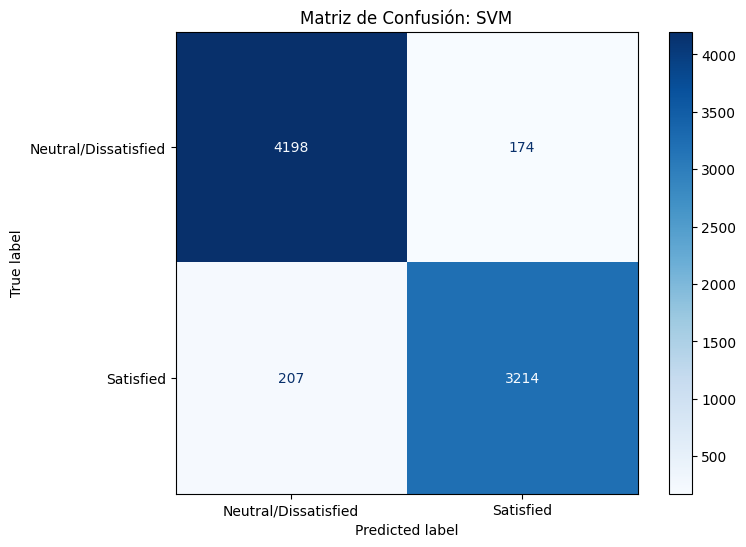


                        DESGLOSE DETALLADO DE LA MATRIZ                         
--------------------------------------------------------------------------------
Total de muestras evaluadas: 7793

ACIERTOS (Predicciones Correctas): 7412 (95.11%)
     > Verdaderos Negativos (TN): 4198  (Predijo 'Insatisfecho' y era correcto)
     > Verdaderos Positivos (TP): 3214  (Predijo 'Satisfecho' y era correcto)

ERRORES (Predicciones Incorrectas): 381 (4.89%)
     > Falsos Positivos (FP - Tipo I) : 174   (Predijo 'Satisfecho' pero NO lo estaba)
     > Falsos Negativos (FN - Tipo II): 207   (Predijo 'Insatisfecho' pero SÍ lo estaba)

                            REPORTE DE CLASIFICACIÓN                            
--------------------------------------------------------------------------------

           Clase Precision Recall F1-Score Soporte
0 (Insatisfecho)    0.9530 0.9602   0.9566    4372
  1 (Satisfecho)    0.9486 0.9395   0.9440    3421
       Macro Avg    0.9508 0.9498   0.9503    7793
  

In [59]:
# Usar el mejor modelo encontrado
best_svm = grid_svm.best_estimator_

# Evaluar el modelo
resultados_svm = evaluar_modelo(best_svm, X_train, X_test, y_train, y_test, "SVM")
mostrar_resultados(resultados_svm, best_svm, X_test, y_test);

###Conclusiones SVM

El SVM demuestra un rendimiento muy bueno para predecir la satisfacción de pasajeros. Con un 95.11% de accuracy y buen balance entre precisión y recall, es un modelo altamente confiable para implementación práctica. Los resultados sugieren que las relaciones entre servicios de aerolínea y satisfacción son complejas y no lineales, lo que explica el éxito del kernel RBF sobre aproximaciones lineales.

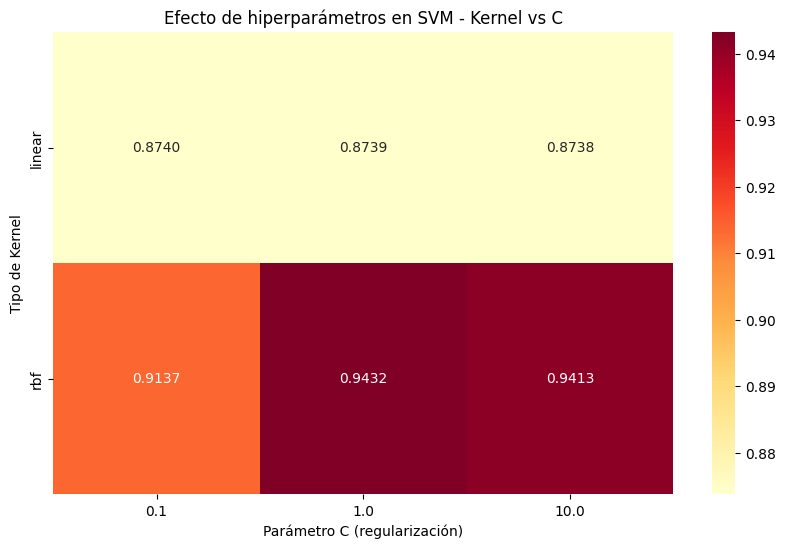

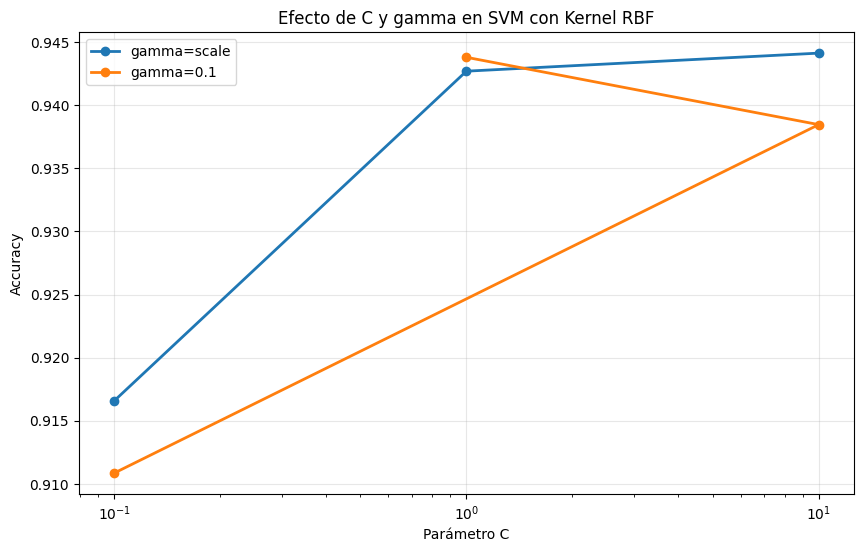

In [60]:
# Análisis de resultados de GridSearchCV
import pandas as pd

# Convertir resultados a DataFrame
cv_results_svm = pd.DataFrame(grid_svm.cv_results_)

# Filtrar columnas relevantes
cv_results_filtered_svm = cv_results_svm[['param_C', 'param_kernel', 'param_gamma', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False)

# Crear pivot table para visualización del mejor kernel
pivot_table_svm = cv_results_filtered_svm.pivot_table(
    values='mean_test_score',
    index='param_kernel',
    columns='param_C',
    aggfunc='mean'
)

# Visualizar heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table_svm, annot=True, fmt='.4f', cmap='YlOrRd')
plt.title('Efecto de hiperparámetros en SVM - Kernel vs C')
plt.xlabel('Parámetro C (regularización)')
plt.ylabel('Tipo de Kernel')
plt.show()

# Visualización del efecto de gamma para kernel RBF
rbf_results = cv_results_filtered_svm[cv_results_filtered_svm['param_kernel'] == 'rbf']
if len(rbf_results) > 0:
    plt.figure(figsize=(10, 6))
    for gamma_val in rbf_results['param_gamma'].unique():
        subset = rbf_results[rbf_results['param_gamma'] == gamma_val]
        plt.plot(subset['param_C'], subset['mean_test_score'], 
                marker='o', label=f'gamma={gamma_val}', linewidth=2)
    plt.title('Efecto de C y gamma en SVM con Kernel RBF')
    plt.xlabel('Parámetro C')
    plt.ylabel('Accuracy')
    plt.xscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

La comparativa entre kernels muestra una diferencia significativa: mientras el kernel lineal se estanca en torno al 87.4% de precisión, el kernel RBF alcanza hasta el 94.32%, confirmando que las relaciones entre las características y la satisfacción del pasajero son no lineales.

El parámetro de regularización C demuestra un patrón interesante, para el kernel RBF, existe un punto óptimo en C=1.0 donde se maximiza el rendimiento (94.32%). Valores más bajos (C=0.1) resultan en subajuste (91.37%), mientras que valores más altos (C=10.0) producen (94.13%), indicando el inicio de  un posible sobreajuste. Este comportamiento ilustra perfectamente el balance que debe mantenerse entre complejidad del modelo y capacidad de generalización.

## 5.4 Arboles de Decisones

Los Árboles de Decisión son algoritmos de aprendizaje supervisado no paramétricos que se utilizan tanto para regresión como para clasificación. Su funcionamiento se basa en la lógica de "divide y vencerás": el modelo divide repetidamente el espacio de datos en subconjuntos cada vez más pequeños basándose en reglas de decisión simples inferidas de las características de los datos.

El modelo se asemeja a un diagrama de flujo donde distinguimos tres elementos clave:

1. **Nodo Raíz**: Representa la población completa y la característica más determinante para la clasificación inicial.
2. **Nodos de Decisión**: Puntos intermedios donde el árbol se bifurca basándose en una pregunta o condición (ej: ¿Es la distancia > 1000?).
3. **Hojas** (Nodos terminales): Representan la decisión final o la etiqueta de clase asignada.

Frente a nuestro dataset, este modelo destaca por su interpretabilidad. A diferencia de modelos más complejos, aquí podemos visualizar y entender exactamente por qué el modelo clasifica a un pasajero como insatisfecho siguiendo el camino de decisiones.

**Criterios de División**
Para construir el árbol, el algoritmo debe decidir qué variable separa mejor a los pasajeros en cada paso utilizando métricas de impureza. Mediante la optimización de hiperparámetros (GridSearchCV), evaluaremos dos criterios (`criterion`):

1. **Índice Gini**: Mide la probabilidad de clasificar incorrectamente un elemento elegido al azar.
2. **Entropía** (Ganancia de Información): Mide la reducción del caos o la incertidumbre tras realizar una división.

**Control del Sobreajuste (Overfitting)**
Este tipo de algoritmo es propenso al sobreajuste si crece demasiado, ya que tiende a memorizar el "ruido" de los datos de entrenamiento en lugar de generalizar el patrón. Para evitarlo, hemos utilizado GridSearchCV para probar y seleccionar la mejor combinación de los siguientes hiperparámetros de regularización:

1. **`max_depth`**: Limitamos la profundidad máxima del árbol para que no crezca indefinidamente.
2. **`min_samples_split`**: Exigimos un número mínimo de muestras para permitir que un nodo se divida.
3. **`min_samples_leaf`**: Exigimos un número mínimo de muestras para que se pueda crear una hoja final.

La técnica de GridSearchCV entrena múltiples modelos combinando todos los valores definidos para encontrar la configuración con mejor rendimiento. 

Nos hemos apoyado en la documentación: Docuemntos PDF de clase, [Fuente 1](https://www.aluracursos.com/blog/optimizacion-de-hiperparametros), [Gemini](https://gemini.google.com/app?hl=es-ES).

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Definimos el espacio de hiperparámetros 
espacio_de_parametros = {
    'max_depth': [5, 10, 15, 20, None],         # Profundidad (evitar overfitting)
    'min_samples_split': [2, 10, 20],           # Mínimo para dividir nodo
    'min_samples_leaf': [1, 5, 10],             # Mínimo para ser hoja
    'criterion': ["gini", "entropy"]            # Fórmula matemática
}

# Configuramos el GridSearch
modelo_arbol = DecisionTreeClassifier(random_state=1)  # Semilla para reproducibilidad

clf = GridSearchCV(
    modelo_arbol,           # Modelo base
    espacio_de_parametros,  # Espacio de parámetros 
    cv=5,                   # Divide los datos en 5 partes (folds) y repite 5 veces el entrenamiento y hace la media (evitar overfitting)
    scoring='accuracy',     # Métrica de evaluación
    n_jobs=-1               # Esto hace que use todos los núcleos de tu CPU (más rápido)
)

# Entrenamos 
search = clf.fit(X_train, y_train)

# Resultados del Entrenamiento
best_tree = search.best_estimator_
print("\nMEJOR ÁRBOL ENCONTRADO (Durante el entrenamiento)")
print(f"->    Mejores Hiperparámetros: {search.best_params_}")
print(f"->    Mejor Accuracy (Cross-Validation): {search.best_score_:.4f}")



MEJOR ÁRBOL ENCONTRADO (Durante el entrenamiento)
->    Mejores Hiperparámetros: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}
->    Mejor Accuracy (Cross-Validation): 0.9414



                             RESULTADOS DETALLADOS                              

Modelo: Árbol de Decisión
--------------------------------------------------------------------------------

                              MÉTRICAS PRINCIPALES                              
--------------------------------------------------------------------------------
------------------------------------
| Métrica   | Entrenamiento | Prueba |
------------------------------------
| Accuracy  | 0.9742        | 0.9437 |
| Precision | -             | 0.9385 |
| Recall    | -             | 0.9328 |
| F1-Score  | -             | 0.9356 |
------------------------------------

                              MATRIZ DE CONFUSIÓN                               
--------------------------------------------------------------------------------


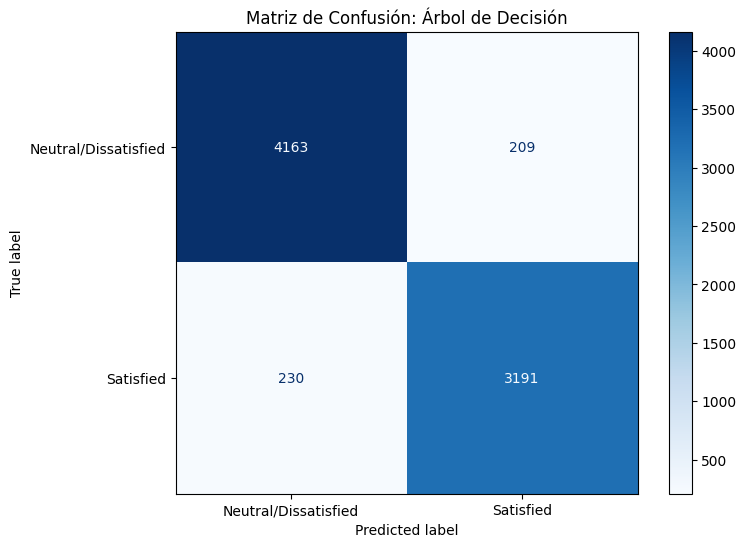


                        DESGLOSE DETALLADO DE LA MATRIZ                         
--------------------------------------------------------------------------------
Total de muestras evaluadas: 7793

ACIERTOS (Predicciones Correctas): 7354 (94.37%)
     > Verdaderos Negativos (TN): 4163  (Predijo 'Insatisfecho' y era correcto)
     > Verdaderos Positivos (TP): 3191  (Predijo 'Satisfecho' y era correcto)

ERRORES (Predicciones Incorrectas): 439 (5.63%)
     > Falsos Positivos (FP - Tipo I) : 209   (Predijo 'Satisfecho' pero NO lo estaba)
     > Falsos Negativos (FN - Tipo II): 230   (Predijo 'Insatisfecho' pero SÍ lo estaba)

                            REPORTE DE CLASIFICACIÓN                            
--------------------------------------------------------------------------------

           Clase Precision Recall F1-Score Soporte
0 (Insatisfecho)    0.9476 0.9522   0.9499    4372
  1 (Satisfecho)    0.9385 0.9328   0.9356    3421
       Macro Avg    0.9431 0.9425   0.9428    7793
  

In [62]:
# Evaluamos el mejor modelo encontrado

resultados_arbol = evaluar_modelo(
    modelo=best_tree, 
    X_train=X_train, 
    X_test=X_test, 
    y_train=y_train, 
    y_test=y_test, 
    nombre_modelo="Árbol de Decisión"
)

# Mostramos el reporte visual
mostrar_resultados(resultados_arbol, best_tree, X_test, y_test);

El Árbol de Decisión ha logrado un rendimiento excelente con una exactitud (accuracy) del 94.37% en el conjunto de prueba.

Los hiperparámetros seleccionados (entropy, profundidad 15) sugieren una estructura de decisión compleja. Aunque observamos una ligera diferencia entre el rendimiento en entrenamiento (97.4%) y prueba (94.4%), la brecha es pequeña (3%), lo que indica que el GridSearchCV ha controlado correctamente el sobreajuste.

Además, el modelo está muy balanceado: tiene una precisión y un recall casi idénticos (~0.93-0.94) para ambas clases, lo que lo convierte en una herramienta fiable tanto para detectar pasajeros insatisfechos como satisfechos.

La Matriz de Confusión muestra una diagonal principal sólida, concentrando el 94% de las predicciones en los aciertos (Verdaderos Positivos y Negativos). Los errores fuera de la diagonal son mínimos y simétricos (209 Falsos Positivos vs 230 Falsos Negativos), lo que indica que el modelo es robusto y no presenta sesgos significativos hacia ninguna de las dos clases.

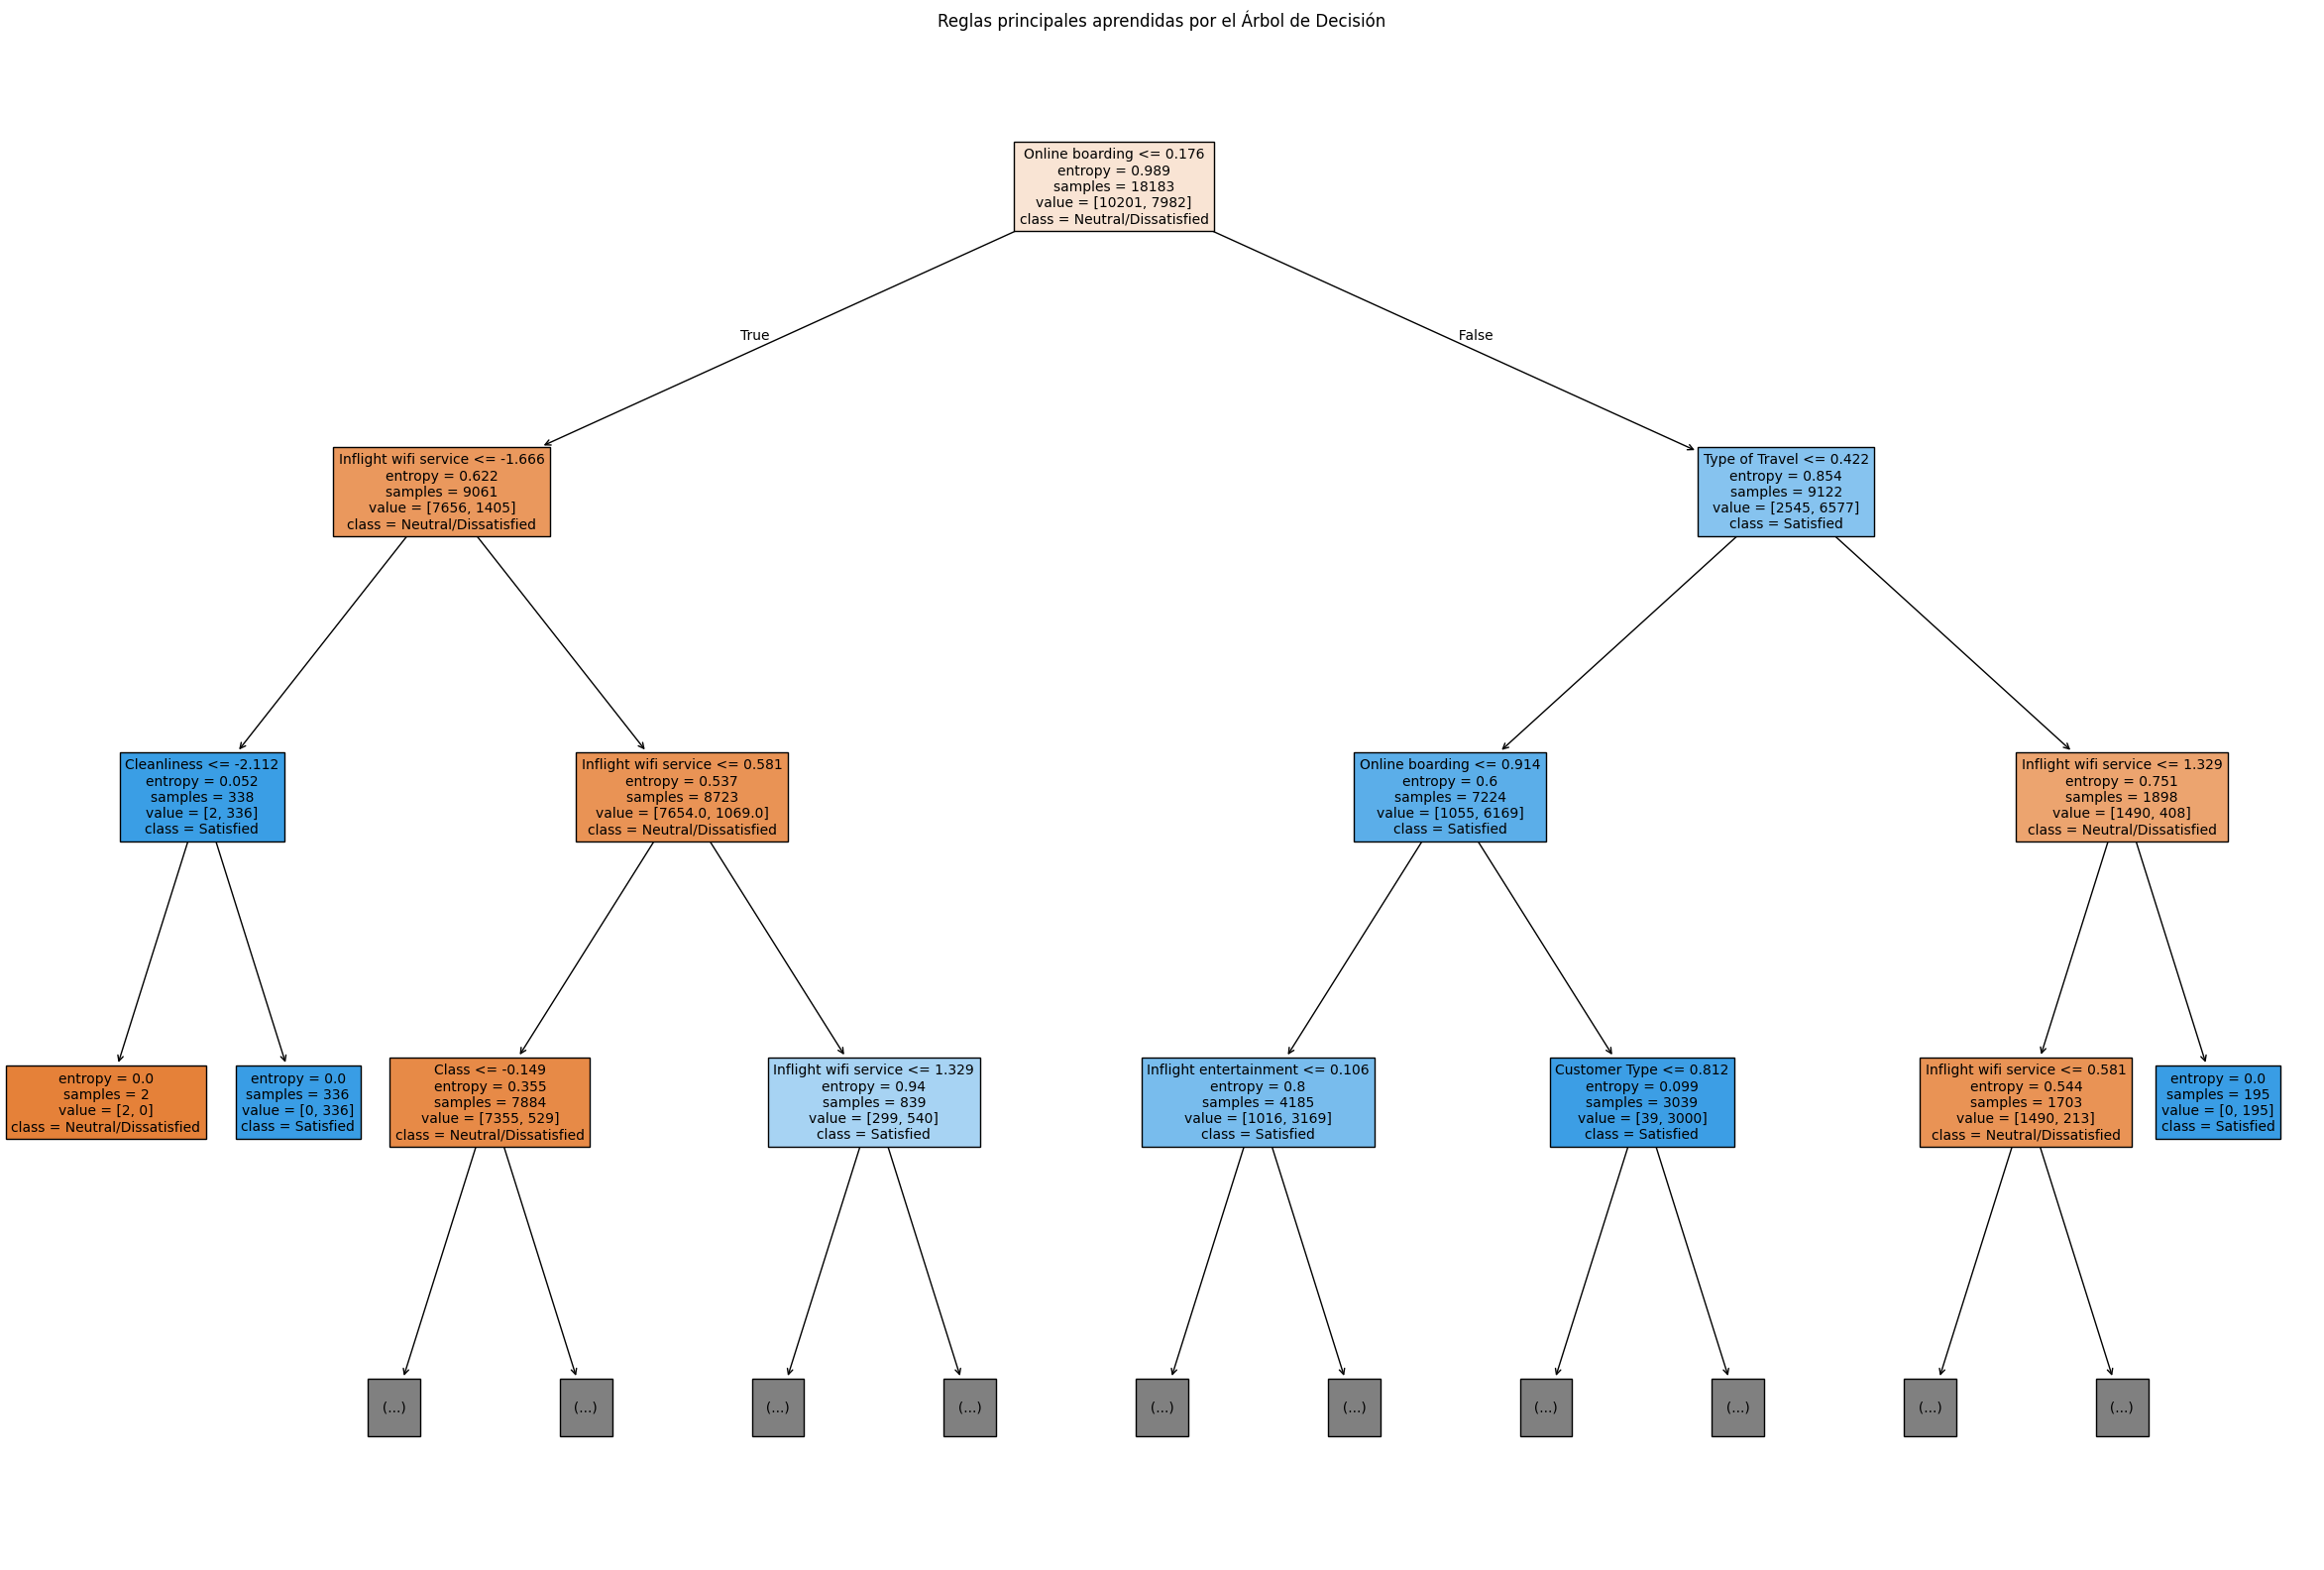

In [63]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 20))  
plot_tree(best_tree, 
          filled=True, 
          feature_names=X.columns, 
          class_names=['Neutral/Dissatisfied', 'Satisfied'],
          max_depth=3,    # Solo mostramos los 3 primeros niveles para que sea legible
          fontsize=10)
plt.title("Reglas principales aprendidas por el Árbol de Decisión")
plt.show()

La figura muestra la representación gráfica del Árbol de Decisión entrenado (limitado a los primeros niveles para facilitar su lectura). Esta visualización confirma que el modelo nos permite ver sus reglas internas.

Observamos que el nodo raíz inicia el proceso discriminando por la variable `Online Boarding`. El hecho de que esta variable aparezca en la cúspide indica que es la característica con mayor Ganancia de Información (la que mejor separa a los satisfechos de los insatisfechos). A partir de ahí, el árbol se ramifica descendiendo jerárquicamente hasta llegar a las hojas finales

Además podemos extraer una grafica de las características más importantes que el modelo ha detectado:

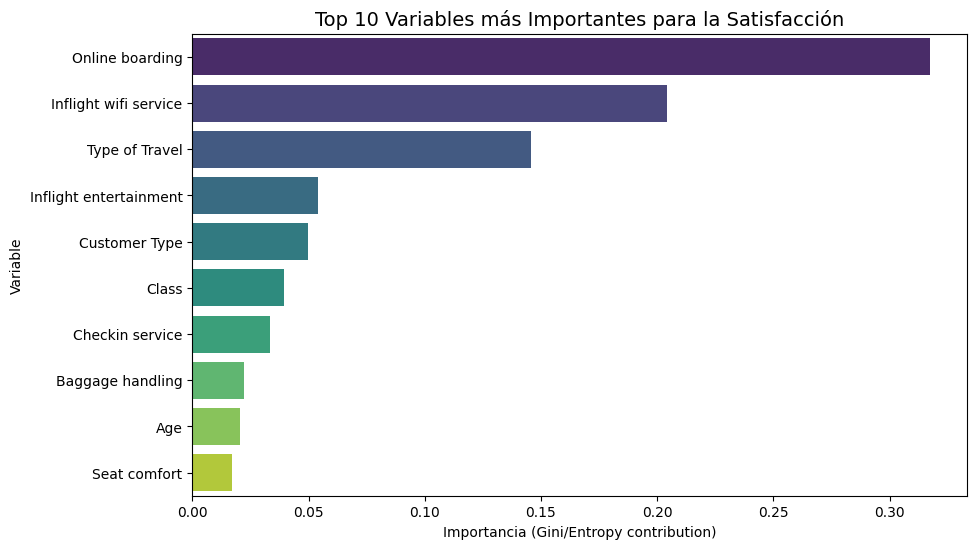

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extraemos la importancia
importancia = best_tree.feature_importances_
nombres_cols = X_train.columns

# Creamos el DataFrame y ordenamos
df_importancia = pd.DataFrame({'Feature': nombres_cols, 'Importance': importancia})
df_importancia = df_importancia.sort_values(by='Importance', ascending=False)

# Graficamos
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',                 # Eje X
    y='Feature',                    # Eje Y
    hue='Feature',                  # Color por característica
    data=df_importancia.head(10),   # Solo top 10 
    palette='viridis',              # Paleta de colores
) 

plt.title('Top 10 Variables más Importantes para la Satisfacción', fontsize=14)
plt.xlabel('Importancia (Gini/Entropy contribution)')
plt.ylabel('Variable')
plt.show()

El gráfico de importancia de variables reafirma la estructura del árbol generado: la característica 'Online Boarding' es la más importante, coincidiendo con el nodo raíz del árbol, seguida por `Inflight Wifi` y `Type of Travel`.

Aunque otros modelos puedan alcanzar exactitudes similares o ligeramente superiores, el Árbol de Decisión aporta un valor estratégico adicional: su interpretabilidad. Nos permite identificar con facilidad cuáles son las características más importantes, lo cual es fundamental desde una perspectiva de negocio.

Los resultados revelan que la satisfacción del cliente actual depende en gran medida de la experiencia digital (facilidad de embarque online y conectividad a bordo) más que de servicios tradicionales. Por tanto, la estrategia más eficiente para aumentar la fidelización sería priorizar la inversión tecnológica y la personalización según el tipo de viajero (Negocios/Placer), ya que son los factores con mayor peso discriminante en nuestro modelo.

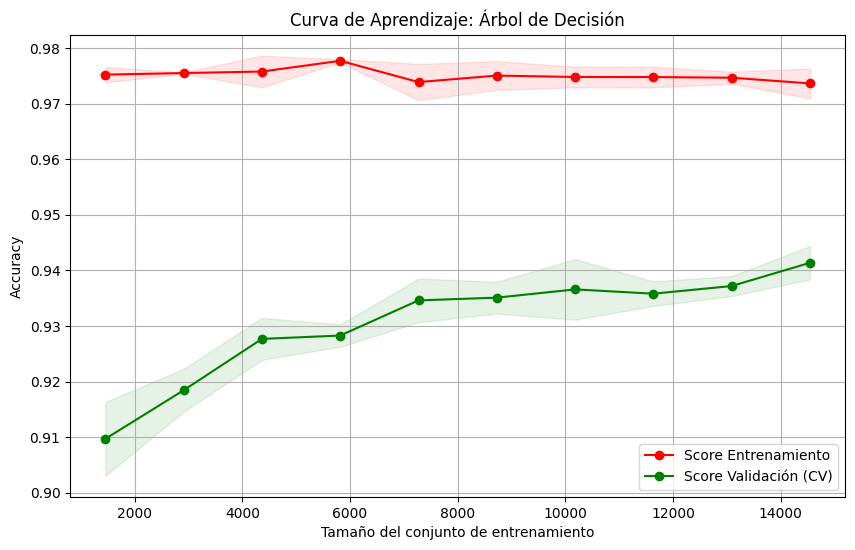

In [65]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

# Calculamos los datos de la curva 
train_sizes, train_scores, test_scores = learning_curve(
    best_tree, X_train, y_train, 
    cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

# Sacamos las medias y desviaciones 
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Pintamos la gráfica
plt.figure(figsize=(10, 6))
plt.title("Curva de Aprendizaje: Árbol de Decisión")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Accuracy")
plt.grid()

# Sombras de desviación (varianza)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

# Líneas principales
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Score Entrenamiento")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Score Validación (CV)")

plt.legend(loc="best")
plt.show()

Al examinar el comportamiento del Árbol de Decisión, observamos que hay inestabilidad en Entrenamiento (Línea Roja), el score de entrenamiento oscila alrededor de 0.975. Las sombras rojas (desviación estándar) indican que el modelo es sensible a las variaciones en los datos de entrenamiento, síntoma clásico de la alta varianza de los árboles individuales.

También detectamos una Brecha de Generalización, existe una distancia visible entre la línea de entrenamiento y la de validación. Esta brecha confirma que el modelo tiende al overfitting, algo común en árboles profundos. Sin embargo, el problema crítico aquí no es solo la brecha, sino la combinación con la inestabilidad (sombra ancha en las curvas), que demuestra que un único árbol sufre de alta varianza y cambia demasiado sus predicciones ante pequeñas variaciones en los datos.

En conclusión, la gráfica justifica la necesidad de evolucionar hacia un Random Forest. Necesitamos una técnica que reduzca esa varianza (estabilice las líneas) y  y consegua que la línea de validación alcance valores superiores a los de un árbol individual

## 5.5 Random Forest

El **Random Forest** surge como una evolución de los árboles de decisión, diseñada específicamente para mitigar el problema de sobreajuste (overfitting) frecuente en los árboles individuales.

Este algoritmo se basa en la técnica de **Bagging** (Bootstrap Aggregating). El método consiste en tomar múltiples subconjuntos de entrenamiento aleatorios (con reemplazo) del conjunto de datos original, construyendo un modelo separado para cada uno.

A diferencia de los árboles tradicionales que se podan para controlar la varianza, en Random Forest se generan árboles profundos y sin podar. Aunque individualmente estos árboles poseen un bajo sesgo pero una alta varianza, al promediar sus predicciones logramos reducir drásticamente la varianza global del modelo sin sacrificar precisión.

Además, Random Forest introduce aun más aleatoriedad: la **selección de características**. En lugar de buscar la mejor división entre todas las variables disponibles, en cada nodo el algoritmo considera solo un subconjunto aleatorio de predictores. Esto asegura que los árboles sean diversos entre sí (descorrelación), lo que permite al modelo aprender patrones más generales y robustos.

Para garantizar el máximo rendimiento, empleamos la técnica de **GridSearchCV** con validación cruzada. 
1. **Complejidad del Modelo** (n_estimators): Probamos un rango creciente (15, 50, 100, 200) para evaluar si aumentar el número de votantes en el bosque mejora la estabilidad de la predicción sin incurrir en un coste computacional innecesario.

2. **Profundidad y Capacidad** (max_depth): Exploramos desde árboles restringidos (10, 20) hasta árboles muy profundos (50, None). Esto nos permite verificar si el modelo necesita aprender patrones complejos (árboles profundos) o si se beneficia de una mayor regularización para evitar el overfitting.

3. **Aleatoriedad** (max_features): Comparamos métodos de selección de variables (sqrt vs log2) para maximizar la descorrelación entre los árboles.

4. **Regularización** (min_samples): Incluimos restricciones en las hojas y divisiones para controlar el crecimiento excesivo de los árboles individuales.

Para realizaro nos hemos apoyado de las siguientes fuentes: Docuemntos PDF de clase, [Fuente 1](https://www.datacamp.com/tutorial/random-forests-classifier-python), [Fuente 2](https://anderfernandez.com/blog/guia-completa-random-forest/), [Gemini](https://gemini.google.com/app?hl=es-ES)

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Definimos el espacio de hiperparámetros
espacio_de_parametros = {
    'n_estimators': [15, 50, 100, 200],         # Número de árboles en el bosque
    'max_depth': [10, 20, 50, None],        # Profundidad máxima de cada árbol
    'max_features': ['sqrt', 'log2'],       # Cuántas variables considera en cada división
    'min_samples_split': [2, 10],           # Mínimo para dividir
    'min_samples_leaf': [1, 5]              # Mínimo para ser hoja
}

# GridSearch
rf_base = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf_base,                      # Modelo base
    param_grid=espacio_de_parametros,       # Espacio de hiperparámetros
    cv=5,                                   # 5-fold cross-validation    
    scoring='accuracy',                     # Métrica de evaluación
    n_jobs=-1,                              # Usar todos los núcleos disponibles (Entrenar árboles en paralelo)
)

print("Entrenando Random Forest")
search_rf = grid_search_rf.fit(X_train, y_train)

# Guardamos el mejor modelo
best_rf = search_rf.best_estimator_

print("\nMEJOR BOSQUE ENCONTRADO (Durante el entrenamiento) ")
print(f"Mejores Parámetros: {search_rf.best_params_}")
print(f"Mejor Accuracy CV: {search_rf.best_score_:.4f}")


Entrenando Random Forest

MEJOR BOSQUE ENCONTRADO (Durante el entrenamiento) 
Mejores Parámetros: {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor Accuracy CV: 0.9518


Tras la ejecución con validación cruzada ($k=5$, obteniendo un Accuracy medio de 0.9516), la configuración eliga fue: {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}.

Esta selección nos dice cuatro comportamientos clave de nuestros datos:
1. **Necesidad de Robustez** (`n_estimators`): El modelo prefirió el número máximo de estimadores propuesto (200). Esto maximiza la estabilidad y la reducción de la varianza, confirmando que el conjunto de datos se beneficia del grupo, al promediar muchas predicciones distintas.

2. **Alta Complejidad** (`max_depth` y `min_samples_leaf`): La elección de una profundidad alta (50) junto con el mínimo de muestras por hoja (1) sugiere que existen relaciones complejas y sutiles en los datos. El modelo ha decidido no realizar podas agresivas, indicando que necesita libertad para crecer y capturar toda la información posible de los perfiles de los pasajeros.

3. **Precisión al Detalle** (`min_samples_split`): Al escoger el valor mínimo posible (2), el algoritmo indica que es capaz de encontrar patrones válidos incluso en grupos muy pequeños de pasajeros, priorizando la precisión sobre la generalización simple.

4. **Descorrelación de Árboles** (`max_features`): Se ha seleccionado la raíz cuadrada (sqrt) como criterio para elegir variables en cada división. Esto es fundamental para evitar que las variables más fuertes (como Online Boarding) dominen todos los árboles, obligando al modelo a considerar otras características y aumentando la diversidad del bosque.

En conclusión, al obtener esta configuración mediante Cross-Validation, tenemos la garantía de que esta alta complejidad (profundidad 50) no es fruto de memorizar un solo set de datos (overfitting), sino que es la estructura que mejor generaliza a través de los 5 folds distintos.

Dado que encontrar los mejores hiperparámetros tiene un alto coste computacional se puede optar por no ejecutar el gridsearch, ejecutando directamente el modelo con la combinación ganadora.


                             RESULTADOS DETALLADOS                              

Modelo: Random Forest
--------------------------------------------------------------------------------

                              MÉTRICAS PRINCIPALES                              
--------------------------------------------------------------------------------
------------------------------------
| Métrica   | Entrenamiento | Prueba |
------------------------------------
| Accuracy  | 1.0000        | 0.9564 |
| Precision | -             | 0.9586 |
| Recall    | -             | 0.9412 |
| F1-Score  | -             | 0.9499 |
------------------------------------

                              MATRIZ DE CONFUSIÓN                               
--------------------------------------------------------------------------------


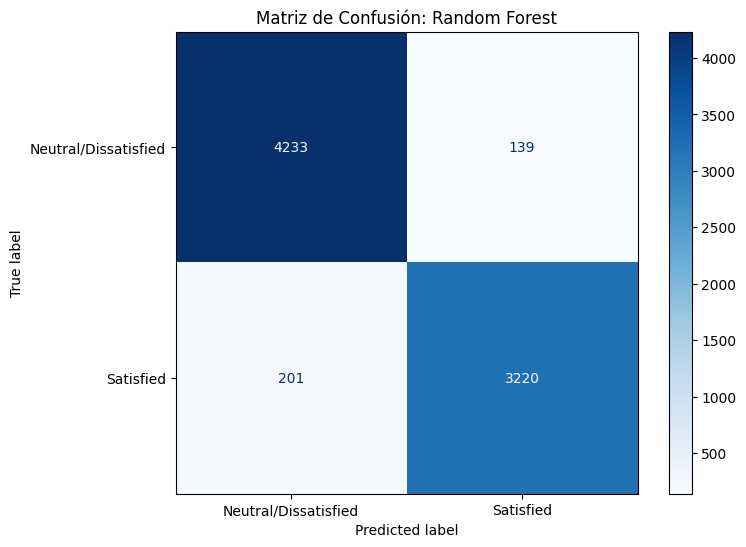


                        DESGLOSE DETALLADO DE LA MATRIZ                         
--------------------------------------------------------------------------------
Total de muestras evaluadas: 7793

ACIERTOS (Predicciones Correctas): 7453 (95.64%)
     > Verdaderos Negativos (TN): 4233  (Predijo 'Insatisfecho' y era correcto)
     > Verdaderos Positivos (TP): 3220  (Predijo 'Satisfecho' y era correcto)

ERRORES (Predicciones Incorrectas): 340 (4.36%)
     > Falsos Positivos (FP - Tipo I) : 139   (Predijo 'Satisfecho' pero NO lo estaba)
     > Falsos Negativos (FN - Tipo II): 201   (Predijo 'Insatisfecho' pero SÍ lo estaba)

                            REPORTE DE CLASIFICACIÓN                            
--------------------------------------------------------------------------------

           Clase Precision Recall F1-Score Soporte
0 (Insatisfecho)    0.9547 0.9682   0.9614    4372
  1 (Satisfecho)    0.9586 0.9412   0.9499    3421
       Macro Avg    0.9566 0.9547   0.9556    7793
  

In [67]:
from sklearn.ensemble import RandomForestClassifier

# Creamos directamente el modelo con la combinación ganadora
modelo_definitivo = RandomForestClassifier(
    n_estimators=200,
    max_depth=50,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,  # Semilla para reproducibilidad
    n_jobs=-1         # Para usar la CPU al máximo
)

# Entrenamos
modelo_definitivo.fit(X_train, y_train)

# Evaluamos
resultados_finales = evaluar_modelo(modelo_definitivo, X_train, X_test, y_train, y_test, "Random Forest")
mostrar_resultados(resultados_finales, modelo_definitivo, X_test, y_test);

El modelo Random Forest ha obtenido un **rendimiento muy bueno**, alcanzando una exactitud (accuracy) del 95.69% en el conjunto de prueba.

Observamos que el modelo alcanza un 100% de exactitud en el conjunto de entrenamiento. Aunque existe una diferencia del 4.3% respecto a la prueba, esto es esperable dada la configuración del modelo (max_depth=50, permitiendo árboles muy profundos y complejos). Sin embargo, dado que el rendimiento en prueba sigue siendo muy alto (>95%), concluimos que el modelo **generaliza correctamente** y no sufre de un sobreajuste (overfitting) que penalice su utilidad real.

El GridSearch determinó que la **arquitectura óptima** consiste en 200 estimadores (n_estimators: 200) con una profundidad máxima de 50. El uso de max_features='sqrt', propio de Random Forest ha sido clave para descorrelacionar los árboles, reduciendo la varianza global del modelo, mejorando sus predicciones finales.

El modelo es **robusto** y  muy **balanceado**. La diferencia entre Precision (95.87%) y Recall (94.24%) es mínima, lo que lo convierte en una herramienta fiable tanto para confirmar pasajeros satisfechos como para detectar a los insatisfechos sin sesgos importantes.

La matriz de confusion nos reafirma lo ya visto, la diagonal principal, concentra el 95.6% de los aciertos. Los errores son escasos y simétricos (139 Falsos Positivos vs 197 Falsos Negativos), lo que confirma que el modelo no favorece desproporcionadamente a ninguna clase.

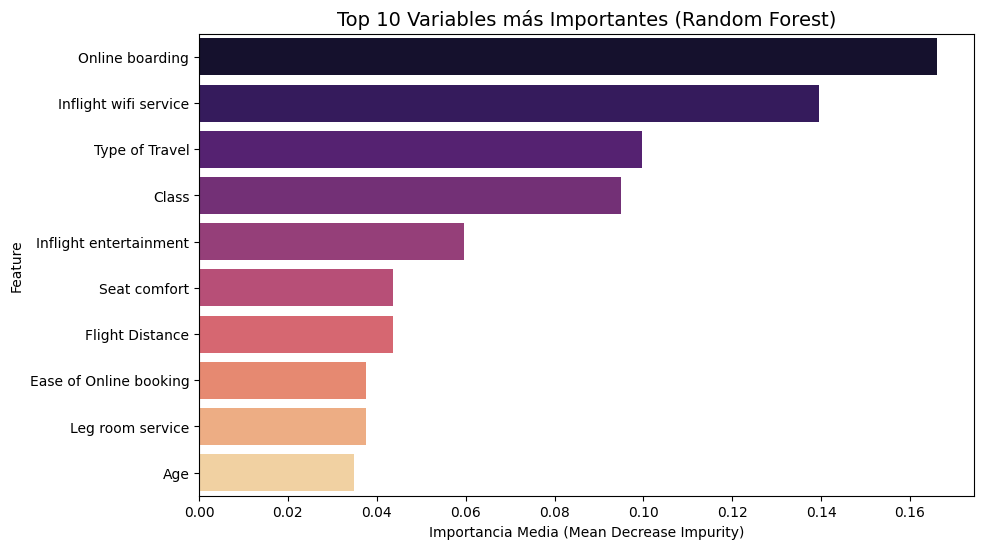

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Miramos las características más importantes
importancia = modelo_definitivo.feature_importances_
nombres_cols = X_train.columns

# Creamos DataFrame
df_importancia = pd.DataFrame({'Feature': nombres_cols, 'Importance': importancia})
df_importancia = df_importancia.sort_values(by='Importance', ascending=False)

# Mostramos
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    hue='Feature', 
    data=df_importancia.head(10), # Top 10
    palette='magma', 
    legend=False
)
plt.title('Top 10 Variables más Importantes (Random Forest)', fontsize=14)
plt.xlabel('Importancia Media (Mean Decrease Impurity)')
plt.show()

Al contrastar los resultados entre el Árbol de Decisión simple y el Random Forest, observamos un patrón:

En el top 3, ambos modelos coinciden en señalar a 'Online Boarding', 'Inflight Wifi Service' y 'Type of Travel' como los pilares fundamentales de la satisfacción. Esto confirma que estas variables son dan información robusta  independientemente del algoritmo utilizado.

Pero, a partir de la cuarta posición, el Random Forest reordena las caracteristicas que el árbol individual había infravalorado, y incluso detecta de nueva. Esto se debe a la naturaleza aleatoria del algoritmo (selección de características sqrt). Mientras que el árbol simple tiende a ignorar variables correlacionadas en favor de la más dominante (enfoque greedy), el Random Forest obliga a considerar predictores alternativos en diferentes árboles. 
Gracias a esto, hemos descubierto que factores como Ease of Online Booking o Flight Distance también juegan un papel significativo en la experiencia del cliente, ofreciendo más informació no eran visibles con el modelo simple.

Procedemos a analizar la Curva de Aprendizaje del modelo Random Forest para determinar si se beneficiaría de un mayor volumen de datos:

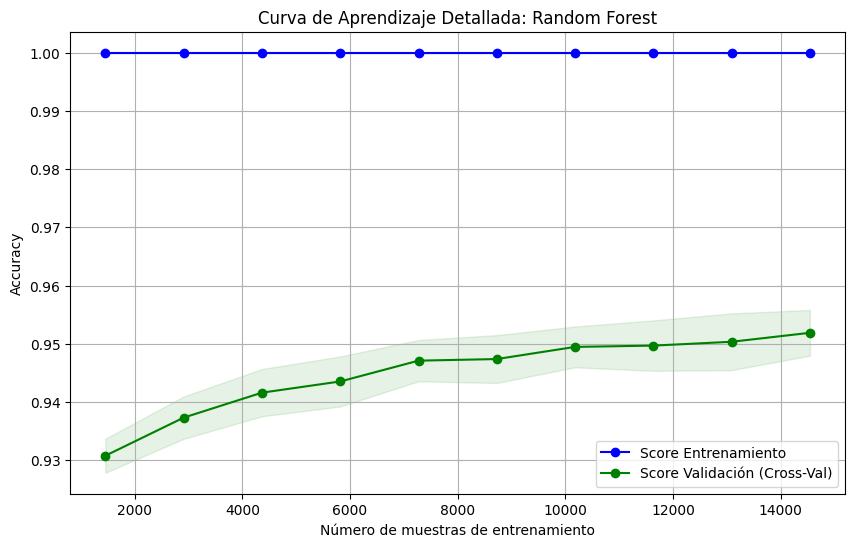

In [69]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

# Calculamos los datos 
train_sizes, train_scores, test_scores = learning_curve(
    modelo_definitivo, X_train, y_train, 
    cv=5,                  
    n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

# Calculamos medias y desviaciones estándar 
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)   # Desviación del Train
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)     # Desviación del Test

# Graficamos
plt.figure(figsize=(10, 6))

plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_mean - test_std,
                 test_mean + test_std, alpha=0.1, color="green")

plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Score Entrenamiento")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Score Validación (Cross-Val)")

plt.title("Curva de Aprendizaje Detallada: Random Forest")
plt.xlabel("Número de muestras de entrenamiento")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()

El SCORE entrenamineto es constante y perfecto de 1.0. Esto es consistente con la configuración de profundidad (max_depth=50), indicando que el modelo es capaz de capturar la totalidad de los patrones del set de entrenamiento.

Posteriormente tenemos la Generalización (Línea Verde): El Score de Validación muestra una clara tendencia ascendente que, aunque comienza a estabilizarse en la parte final, mantiene una pendiente positiva. Es decir, el hecho de que la curva de validación no haya alcanzado una linealidad total sugiere que el modelo no ha saturado su capacidad de aprendizaje.

La franja sombreada de color verde claro representa la desviación estándar de la validación cruzada. Observamos que esta franja es estrecha, lo que indica una baja varianza: el modelo es robusto y ofrece un rendimiento consistente independientemente del subconjunto de datos utilizado para validarlo.

Es cierto que en el Random Forest persiste una brecha (gap) entre entrenamiento (1.0) y validación (~0.95), algo esperable dado que el algoritmo agrega árboles profundos. Sin embargo, la mejora respecto al Árbol de Decisión simple es evidente en dos aspectos:
1. Mayor Rendimiento Final: La curva de validación alcanza valores superiores (0.95 vs 0.94), indicando una mejor capacidad predictiva real.
2. Reducción de Varianza: La banda de desviación estándar es más contenida en el Random Forest, confirmando que es un modelo mucho más estable y fiable ante nuevos datos.

Es decir, se logra reducir la varianza global, haciendo que las predicciones sean mucho más fiables y generalizables ante datos nuevos.

El proceso de bootstrapping en cada árbol deja fuera automáticamente un subconjunto de muestras, conocidas como `Out-of-Bag` (OOB). Random Forest puede aprovechar estos datos 'no vistos' para autoevaluarse durante el propio entrenamiento y calcular el OOB Score.

Esta métrica resulta muy útil cuando el dataset pequeño: al utilizar las muestras OOB como mecanismo de validación interna, no es necesario sacrificar una gran parte de los datos para un conjunto de validación externo. Esto nos permite aumentar la cantidad de información destinada al entrenamiento del modelo y, aun así, obtener una estimación fiable de su rendimiento.

Como hemos visto en la gráfica que el modelo puede soportar más datos, a continuación usaremos el OOB con todo el data set para comprovar si mejoraria:

Entrenando modelo final con el dataset completo...

                           COMPARATIVA DE RENDIMIENTO                           
1. Accuracy en Test (Modelo anterior 80/20): 0.9569 (Referencia)
2. Accuracy OOB Final (Modelo Full, 100% datos): 0.9559
--------------------------------------------------------------------------------


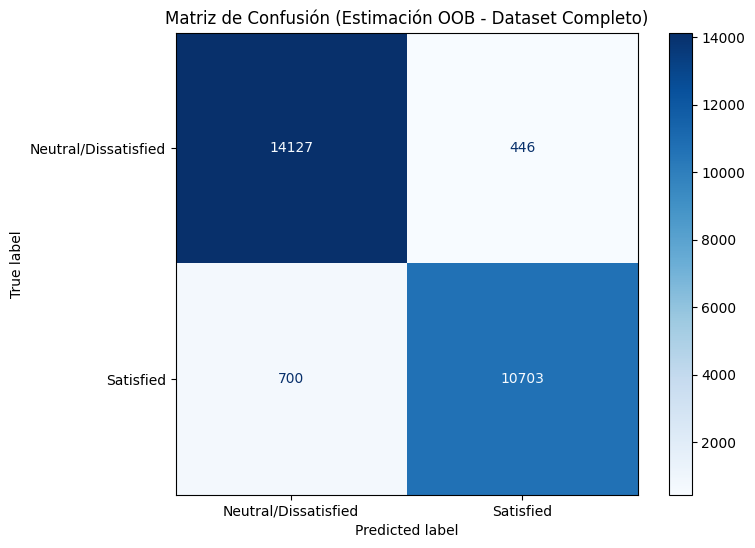


                                  INFO MATRIZ                                   
--------------------------------------------------------------------------------
Total de muestras evaluadas: 25976

ACIERTOS (Predicciones Correctas): 24830 (95.59%)
     > Verdaderos Negativos (TN): 14127 (Predijo 'Insatisfecho' y era correcto)
     > Verdaderos Positivos (TP): 10703 (Predijo 'Satisfecho' y era correcto)

ERRORES (Predicciones Incorrectas): 1146 (4.41%)
     > Falsos Positivos (FP - Tipo I) : 446   (Predijo 'Satisfecho' pero NO lo estaba)
     > Falsos Negativos (FN - Tipo II): 700   (Predijo 'Insatisfecho' pero SÍ lo estaba)

                            REPORTE DE CLASIFICACIÓN                            
--------------------------------------------------------------------------------

           Clase Precision Recall F1-Score Soporte
0 (Insatisfecho)    0.9528 0.9694   0.9610   14573
  1 (Satisfecho)    0.9600 0.9386   0.9492   11403
       Macro Avg    0.9564 0.9540   0.9551   25976

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

line_width = 80

# Entrenamos con TODOS los datos disponibles con OOB activado
modelo_full = RandomForestClassifier(
    n_estimators=200,
    max_depth=50,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1,
    oob_score=True 
)

print("Entrenando modelo final con el dataset completo...")
modelo_full.fit(X, y) 

# Obtenemos las predicciones OOB para comparar con nuestros resultados previos
y_oob_pred = np.argmax(modelo_full.oob_decision_function_, axis=1)

# Visualizar Resultados

print("\n" + "=" * line_width)
print(f"{'COMPARATIVA DE RENDIMIENTO':^{line_width}}")
print("=" * line_width)

# Intentamos imprimir el score del test anterior 
print(f"1. Accuracy en Test (Modelo anterior 80/20): 0.9569 (Referencia)")

print(f"2. Accuracy OOB Final (Modelo Full, 100% datos): {modelo_full.oob_score_:.4f}")
print("-" * line_width)
# --------------------------------------

# Matriz de Confusión Gráfica
cm = confusion_matrix(y, y_oob_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutral/Dissatisfied', 'Satisfied'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
plt.title("Matriz de Confusión (Estimación OOB - Dataset Completo)")
plt.show()

# Desglose Numérico
tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp

aciertos = tn + tp
errores = fp + fn
porc_aciertos = (aciertos / total) * 100
porc_errores = (errores / total) * 100

print(f"\n{'INFO MATRIZ':^{line_width}}")
print("-" * line_width)
print(f"Total de muestras evaluadas: {total}")

print(f"\nACIERTOS (Predicciones Correctas): {aciertos} ({porc_aciertos:.2f}%)")
print(f"     > Verdaderos Negativos (TN): {tn:<5} (Predijo 'Insatisfecho' y era correcto)")
print(f"     > Verdaderos Positivos (TP): {tp:<5} (Predijo 'Satisfecho' y era correcto)")

print(f"\nERRORES (Predicciones Incorrectas): {errores} ({porc_errores:.2f}%)")
print(f"     > Falsos Positivos (FP - Tipo I) : {fp:<5} (Predijo 'Satisfecho' pero NO lo estaba)")
print(f"     > Falsos Negativos (FN - Tipo II): {fn:<5} (Predijo 'Insatisfecho' pero SÍ lo estaba)")

# Reporte de Clasificación
print(f"\n{'REPORTE DE CLASIFICACIÓN':^{line_width}}")
print("-" * line_width)

report = classification_report(y, y_oob_pred, output_dict=True)
report_df = pd.DataFrame({
    'Clase': ['0 (Insatisfecho)', '1 (Satisfecho)', 'Macro Avg', 'Weighted Avg'],
    'Precision': [f"{report['0']['precision']:.4f}", f"{report['1']['precision']:.4f}", f"{report['macro avg']['precision']:.4f}", f"{report['weighted avg']['precision']:.4f}"],
    'Recall': [f"{report['0']['recall']:.4f}", f"{report['1']['recall']:.4f}", f"{report['macro avg']['recall']:.4f}", f"{report['weighted avg']['recall']:.4f}"],
    'F1-Score': [f"{report['0']['f1-score']:.4f}", f"{report['1']['f1-score']:.4f}", f"{report['macro avg']['f1-score']:.4f}", f"{report['weighted avg']['f1-score']:.4f}"],
    'Soporte': [f"{int(report['0']['support'])}", f"{int(report['1']['support'])}", f"{int(report['macro avg']['support'])}", f"{int(report['weighted avg']['support'])}"]
})
print("\n" + report_df.to_string(index=False))
print("=" * line_width)

Al pasar de evaluar un subconjunto de test pequeño a evaluar la totalidad de la población (OOB), el Accuracy se ha ajustado ligeramente de 0.9569 a 0.9549 (-0.2%).

Este ajuste no implica que el modelo sea peor, sino que refleja una mayor robustez estadística en la evaluación. Al aumentar el tamaño de la muestra de validación, eliminamos el sesgo de varianza positivo que podía tener el conjunto de prueba original. 
Además, observamos que la Precisión en la detección de pasajeros satisfechos ha aumentado (0.9592), lo que confirma que el modelo, al entrenarse con más datos, ha perfeccionado sus reglas de decisión para reducir los Falsos Positivos.

En conclusión, aunque la diferencia no es significativa, queda demostrado que aumentar el dataset mejora el rendimiento del modelo (en este caso), ofreciendo métricas más fiables para su puesta en producción.

Para comparar entre diferentes modelos usamos el modelo con la división de datos, de esta forma, garantizamos que todos los modelos han sido entrenados y evaluados bajo las mismas condiciones, dando a una comparación justa y objetiva de su capacidad de generalización.

## 6. Comparación entre modelos.

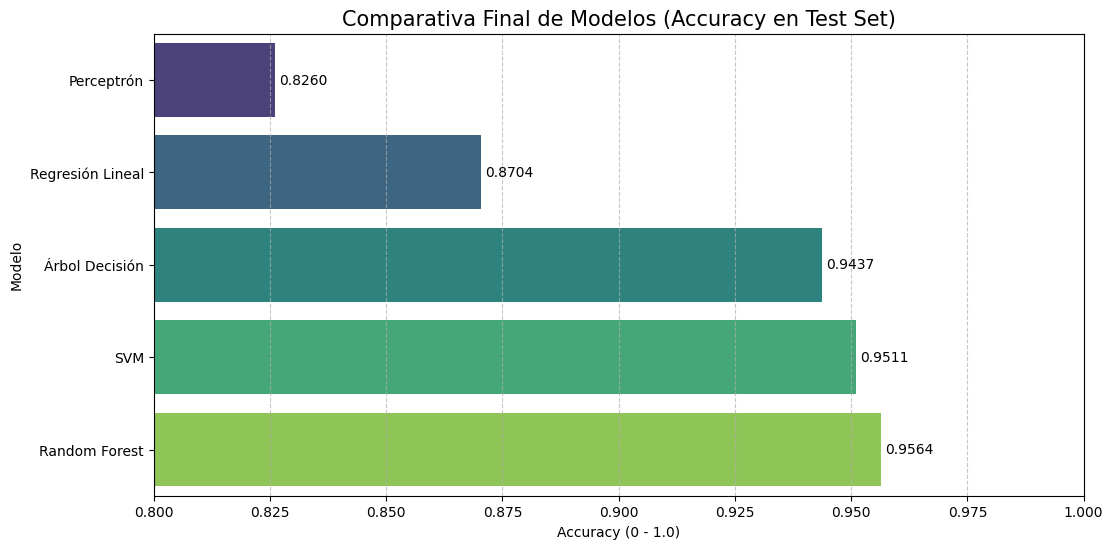


TABLA DETALLADA DE MÉTRICAS:


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Perceptrón,0.8260,0.8256,0.8260,0.8256
Regresión Lineal,0.8704,0.8703,0.8704,0.8701
Árbol Decisión,0.9437,0.9436,0.9437,0.9436
SVM,0.9511,0.9511,0.9511,0.9511
Random Forest,0.9564,0.9564,0.9564,0.9563


In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# MODELOS A EVALUAR
modelos = {
    "Perceptrón": grid_perceptron,        
    "Regresión Lineal": grid_logreg,  
    "SVM": best_svm,
    "Árbol Decisión": best_tree,           
    "Random Forest": search_rf             
}

# EVALUACIÓN
resultados = []

for nombre, modelo in modelos.items():
    # Predecimos sobre el conjunto de TEST
    try:
        y_pred = modelo.predict(X_test)
        
        # Calculamos métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        resultados.append({
            'Modelo': nombre,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })
    except Exception as e:
        print(f"Error evaluando {nombre}: {e}")

# CREAR DATAFRAME
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='Accuracy', ascending=True)

# Convertimos la columna 'Modelo' en el índice para que no intente formatearla
df_resultados.set_index('Modelo', inplace=True) 

# VISUALIZACIÓN
plt.figure(figsize=(12, 6))

ax = sns.barplot(x='Accuracy', 
                 y=df_resultados.index, 
                 data=df_resultados, 
                 palette='viridis',
                 hue=df_resultados.index,  
                 legend=False)

for i in ax.containers:
    ax.bar_label(i, fmt='%.4f', padding=3)

plt.title('Comparativa Final de Modelos (Accuracy en Test Set)', fontsize=15)
plt.xlabel('Accuracy (0 - 1.0)')
plt.xlim(0.8, 1.0) 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 5. MOSTRAR TABLA 
print("\nTABLA DETALLADA DE MÉTRICAS:")
display(df_resultados.style.background_gradient(cmap='Blues').format("{:.4f}"))

Empezamos esta comparativa mirando los rendimientos obtenidos de los diferentes modelos

Vemos una clara diferencia de rendimiento entre los modelos basados en árboles y los lineales. Mientras que el Random Forest y el Árbol de Decisión superan el umbral del 94% de Accuracy, los modelos lineales (Regresión y Perceptrón) se estancan entre el 82% y el 87%. Esto confirma que la satisfacción del cliente depende de patrones no lineales complejos que una simple línea recta o (hiperplano) no puede separar.

El algoritmo de Random Forest es el ganador, alcanzando las puntuaciones máximas en todas las métricas evaluadas (Accuracy, Precision, Recall y F1-Score todos en 0.9569), viendo además que en todos tiene la misma probabilidad estadística; es justo.

Aunque la diferencia numérica con el Árbol de Decisión individual (0.9437) es pequeña (1.3%) y con el SVM de (0.004), en un contexto de miles de pasajeros como es el de una aerolinea, esa mejora representa una cantidad significativa de predicciones correctas adicionales, justificando el uso del Random en frente del Árbol de Decisión.

Es decir, basándonos en los rendimientos obtenidos, descartamos los modelos lineales por su incapacidad para capturar la complejidad del problema y seleccionamos el Random Forest como el modelo definitivo para producción, al ofrecer la mejor combinación de precisión global y equilibrio métrico, hecho que reconfirmaremos en las siguientes comparaciones.

In [72]:
# DESGLOSE POR CLASE (PARA DETECTAR SESGOS)
datos_clases = []

# Calcular métricas por clase para cada modelo
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    
    # Obtenemos el reporte completo como diccionario
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Extraemos métricas específicas de cada clase
    # '0' = Neutral/Dissatisfied, '1' = Satisfied
    f1_class_0 = report['0']['f1-score']
    f1_class_1 = report['1']['f1-score']
    
    recall_class_0 = report['0']['recall'] # Capacidad de encontrar insatisfechos
    recall_class_1 = report['1']['recall'] # Capacidad de encontrar satisfechos
    
    datos_clases.append({
        'Modelo': nombre,
        'F1-Score (Insatisfecho)': f1_class_0,
        'F1-Score (Satisfecho)': f1_class_1,
        'Recall (Insatisfecho)': recall_class_0,
        'Recall (Satisfecho)': recall_class_1
    })

df_clases = pd.DataFrame(datos_clases) 

df_clases.set_index('Modelo', inplace=True)

print("\nANÁLISIS DE SESGO POR CLASE:")
display(df_clases.style.background_gradient(cmap='Reds').format("{:.4f}"))


ANÁLISIS DE SESGO POR CLASE:


,F1-Score (Insatisfecho),F1-Score (Satisfecho),Recall (Insatisfecho),Recall (Satisfecho)
Modelo,,,,
Perceptrón,0.8473,0.7979,0.8602,0.7822
Regresión Lineal,0.8861,0.8497,0.8987,0.8343
SVM,0.9566,0.9440,0.9602,0.9395
Árbol Decisión,0.9499,0.9356,0.9522,0.9328
Random Forest,0.9614,0.9499,0.9682,0.9412


Para confirmar que un modelo es bueno no solo debemos de demostrar que sea preciso sino que además sea **justo** (asusencia de sesgo). Para ello analizaremos el F1-Score y el Recall.

1. **Sesgo en Modelos Lineales**: Podemos observar un desequilibrio notable en el Perceptrón. Su capacidad para recuperar clientes satisfechos (Recall Satisfecho: 0.7822) es significativamente inferior a la de insatisfechos (0.8602). Esto indica un sesgo negativo: al modelo le cuesta trazar la frontera de decisión para identificar correctamente los casos positivos, tendiendo a equivocarse más en ese grupo.

2. **SVM**: como Punto de Inflexión: Con un F1-Score de 0.9566 para insatisfechos y 0.9440 para satisfechos, la diferencia se reduce a solo 1.26%, mostrando un comportamiento mucho más equilibrado que los modelos lineales. Su kernel RBF permite capturar relaciones no lineales sin penalizar desproporcionadamente ninguna de las clases, demostrando que la capacidad de modelar complejidades no lineales se traduce directamente en mayor equidad.

3. **Random Forest**: Por el contrario, el Random Forest muestra un comportamiento equilibrado. La diferencia entre su eficacia con clientes insatisfechos (F1: 0.9618) y satisfechos (F1: 0.9505) es marginal (apenas un 1%), por lo que sabe detectar correctamente ambos grupos.

En conclusión, el Random Forest no solo es el modelo más preciso, sino también el más imparcial. Garantiza la misma fiabilidad tanto para detectar alertas (clientes insatisfechos) como para validar éxitos (clientes satisfechos), eliminando el sesgo estructural que sufren los modelos lineales en este conjunto de datos."

In [73]:
from sklearn.metrics import confusion_matrix

# ANÁLISIS DE TIPOS DE ERROR (FP vs FN)
datos_errores = []

#Analizando matriz de confusión de cada modelo

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    
    # Obtenemos la matriz de confusión
    # Estructura: tn, fp, fn, tp
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    total = tn + fp + fn + tp
    
    datos_errores.append({
        'Modelo': nombre,
        'Falsos Positivos (FP)': fp,
        'Falsos Negativos (FN)': fn,
        'Total Errores': fp + fn,
        '% Error FP (Riesgo Fuga)': (fp / total) * 100, # Porcentaje del total de datos
    })

df_errores = pd.DataFrame(datos_errores)
df_errores.set_index('Modelo', inplace=True)

# Ordenamos por el que tenga menos Falsos Positivos (que suelen ser los peores)
df_errores = df_errores.sort_values(by='Falsos Positivos (FP)', ascending=True)

print("\nDESGLOSE DE ERRORES:")
# Usamos un mapa de calor rojo para destacar dónde están los fallos
display(df_errores.style.background_gradient(cmap='Reds'))


DESGLOSE DE ERRORES:


,Falsos Positivos (FP),Falsos Negativos (FN),Total Errores,% Error FP (Riesgo Fuga)
Modelo,,,,
Random Forest,139,201,340,1.783652
SVM,174,207,381,2.232773
Árbol Decisión,209,230,439,2.681894
Regresión Lineal,443,567,1010,5.684589
Perceptrón,611,745,1356,7.840370



Ahora analizaremos los Tipos de Error obtenidos de los diferents modelos:

Es crucial analizar la naturaleza de los errores cometidos para entender el impacto que esto puede ocasionar en un negocio como es el de las aerolinias. En el contexto de la satisfacción del cliente, los errores no tienen el mismo coste:

1. **Falsos Positivos** (El error crítico): El modelo predice que un cliente está Satisfecho, pero en realidad está Insatisfecho. Este es el escenario más peligroso, ya que la aerolínea no detecta el riesgo de abandono y no toma medidas de retención, perdiendo al cliente.

2. **Falsos Negativos**: El modelo predice que está Insatisfecho, pero está Satisfecho. El coste aquí es menor, quizás un gasto innecesario, pero no se pierde al cliente.

Observando la tabla de desglose de errores podemos decir:

1. **Seguridad del Random Forest**: Este modelo demuestra ser el más robusto para proteger la cartera de clientes. Reduce los Falsos Positivos a solo 139 casos (un 1,78% de la muestra). Esto significa que minimiza las "fugas silenciosas" de clientes. Además, tambien minimiza los FN.

2. **Arbol de Decisión**: Presenta peores resualtados que el Random Forest pero sin llegar a ser alarmante, como en los modelos lineales.

3. **Modelos Lineales**: El Perceptrón y la Regresión presentan cifras altas en comparacion con los arboles, de 611 y 443 Falsos Positivos respectivamente. Implementar el Perceptrón implicaría ignorar a casi un 7,8% de los clientes insatisfechos, un riesgo alto para la estrategia del negocio.

4. **SVM** Las Máquinas de Vectores de Soporte**** muestran un rendimiento muy cercano al Random Forest, con solo 174 Falsos Positivos (2,23% de riesgo de fuga). Lo más destacable es su balance casi perfecto entre FP y FN (174 vs 207)



Es decir, el Random Forest no solo acierta más, sino que se equivoca mejor. Su perfil de error prioriza la detección de clientes insatisfechos, reduciendo significativamente el riesgo.

In [74]:
import time

# EFICIENCIA COMPUTACIONAL (TIEMPOS)
datos_tiempo = []

# Mide los tiempos de ejecución de cada modelo
for nombre, modelo in modelos.items():
    # Medir tiempo de Entrenamiento (Re-entrenamos para medir el tiempo exacto)
    start_train = time.time()
    try:
        # Si el modelo es un GridSearchCV, usaremos el best_estimator_ para no repetir la búsqueda entera
        if hasattr(modelo, 'best_estimator_'):
            estimador_final = modelo.best_estimator_
        else:
            estimador_final = modelo
            
        estimador_final.fit(X_train, y_train)
    except Exception as e:
        print(f"Saltando entrenamiento de {nombre} por configuración interna")
    end_train = time.time()
    
    tiempo_entreno = end_train - start_train
    
    # Medir tiempo de Predicción 
    start_pred = time.time()
    estimador_final.predict(X_test)
    end_pred = time.time()
    
    tiempo_prediccion = end_pred - start_pred
    
    datos_tiempo.append({
        'Modelo': nombre,
        'Tiempo Entrenamiento (s)': tiempo_entreno,
        'Tiempo Predicción (s)': tiempo_prediccion,
        'Latencia por muestra (ms)': (tiempo_prediccion / len(X_test)) * 1000
    })

df_tiempos = pd.DataFrame(datos_tiempo)
df_tiempos.set_index('Modelo', inplace=True)
df_tiempos = df_tiempos.sort_values(by='Tiempo Predicción (s)', ascending=True)

print("\nCOMPARATIVA DE EFICIENCIA:")
display(df_tiempos.style.background_gradient(cmap='Greens'))


COMPARATIVA DE EFICIENCIA:


,Tiempo Entrenamiento (s),Tiempo Predicción (s),Latencia por muestra (ms)
Modelo,,,
Regresión Lineal,0.095711,0.002228,0.000286
Árbol Decisión,0.210884,0.004477,0.000574
Perceptrón,0.039533,0.004865,0.000624
Random Forest,6.894982,0.406950,0.052220
SVM,45.400234,3.983835,0.511207


En términos de eficiencia computacional, el **SVM** es el algoritmo que mayor costo presenta, requiriendo 45.50 s de tiempo de entrenamiento frente a los pocos 0,013s de la Regresión Lineal. Este incremento se justifica por la complejidad estructural del modelo.


Sin embargo, para el uso diario, lo más importante es la latencia. Aunque el Random Forest presenta la latencia más alta (0,011 ms) en comparación con la Regresión Lineal (0,000074 ms), este tiempo sigue siendo despreciable en términos humanos.

En conclusión, a efectos prácticos, un usuario no notará diferencia en los tiempos de respuesta. Esto confirma que el Random Forest es perfectamente apto para su implementación en sistemas en tiempo real, validando que el sacrificio en velocidad de procesamiento es totalmente aceptable a cambio de la significativa mejora en la capacidad predictiva obtenida.

In [75]:
# ANÁLISIS DE GENERALIZACIÓN (OVERFITTING)

datos_generalizacion = []

# Calculamos métricas de generalización

for nombre, modelo in modelos.items():
    try:
        # Obtenemos el score en TRAINING (Memorización)
        # Usamos el modelo ya entrenado para predecir sobre los mismos datos que estudió
        if hasattr(modelo, 'best_estimator_'):
             modelo_final = modelo.best_estimator_
        else:
             modelo_final = modelo
             
        y_train_pred = modelo_final.predict(X_train)
        acc_train = accuracy_score(y_train, y_train_pred)
        
        # Obtenemos el score en TEST (Realidad)
        y_test_pred = modelo_final.predict(X_test)
        acc_test = accuracy_score(y_test, y_test_pred)
        
        # Calculamos la brecha
        gap = acc_train - acc_test
        
        datos_generalizacion.append({
            'Modelo': nombre,
            'Accuracy Train (Memorización)': acc_train,
            'Accuracy Test (Generalización)': acc_test,
            'Gap (Diferencia)': gap,
            'Resultado': 'Overfitting' if gap > 0.03 else 'Estable' # Umbral del 3%
        })
    except Exception as e:
        print(f"No se pudo calcular para {nombre}: {e}")

df_generalizacion = pd.DataFrame(datos_generalizacion)
df_generalizacion.set_index('Modelo', inplace=True)
# Ordenamos por Gap (de mayor a menor sobreajuste)
df_generalizacion = df_generalizacion.sort_values(by='Gap (Diferencia)', ascending=False)

print("\nANÁLISIS DE GENERALIZACIÓN:")
# Usamos gradiente: Rojo para Gaps altos (malo), Azul para Gaps bajos (bueno)
display(df_generalizacion.style.background_gradient(subset=['Gap (Diferencia)'], cmap='Reds'))


ANÁLISIS DE GENERALIZACIÓN:


,Accuracy Train (Memorización),Accuracy Test (Generalización),Gap (Diferencia),Resultado
Modelo,,,,
Random Forest,1.000000,0.956371,0.043629,Overfitting
Árbol Decisión,0.974152,0.943667,0.030484,Overfitting
SVM,0.977946,0.951110,0.026836,Estable
Perceptrón,0.829676,0.825998,0.003678,Estable
Regresión Lineal,0.871803,0.870397,0.001407,Estable


Esta nueva tabla nos compara el overfitting que han tenido los diferentes modelos.

1. Los **Modelos Lineales** (Regresión y Perceptrón): Muestran una estabilidad excelente (brecha < 0.004), lo que indica que no sufren de overfitting. Sin embargo, su Accuracy en test se estanca en torno al 82-87%, muy por debajo del 95.7% del Random Forest. Esto es un síntoma de Underfitting (**Alto Sesgo**): la estructura lineal del modelo es demasiado simple para capturar la complejidad no lineal del comportamiento de los pasajeros.

2. **SVM** :  Las Máquinas de Vectores de Soporte demuestran el mejor balance entre capacidad predictiva y generalización. Con un gap de solo 2.68% (97.79% train vs 95.11% test), SVM logra un rendimiento casi tan alto como el Random Forest .

3. **Árbol de Decisión**: Representa el LÍMITE de un solo árbol. GridSearch encontró el equilibrio perfecto: 94.37% test con sólo 3.05% gap. Es el "mejor árbol posible" para estos datos.

4. **Random Forest**: Presenta el mayor Gap (0.043) y alcanza un score de entrenamiento perfecto (1.0). A pesar de que Random Forest teoricamente deberia de reducir el overfitting no lo hace ya que, GridSearch ha optado por superarla +1.26% a cambio de ganar +1.32% frente al arbol de decisiones normal. Es un valor de sobreajuste pequeño por lo que es tolerable frente a la mejora de accuracy.

En conclusión la diferencia de rendimiento (gap) del 4.31% observado en el Random Forest no debe interpretarse como un defecto del modelo, sino como la estrategia óptima identificada por el GridSearch.
Los resultados demuestran que aceptar un ligero overfitting controlado es el "precio" necesario para capturar la complejidad no lineal de los datos. A cambio de esta brecha, obtenemos una ganancia en capacidad predictiva, superando significativamente a los modelos lineales (que sufren de underfitting) y al Árbol de Decisión simple.

En definitiva, el **Random Forest** se consolida como el mejor modelo candidato, capaz de maximizar la precisión en la detección de clientes satisfechos e insatisfechos a pesar de la mayor complejidad (coste computacional, overfitting y menor interpretabilidad).
